In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import os
import xarray as xr
import numpy as np
from natsort import natsorted
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [56]:
import sys
original_path = os.getcwd()  
os.chdir(original_path)
function_path = './functions/'
sys.path.append(function_path)
from smoothing_function import *
from model_analysis_function import *
from analysis_function import *
from Plot_function import *
from ar6_area_weighted_cont_global import *
# from obs_function import *

## Constrain global temperature
### Load global data

In [57]:
path = '/Users/tongli1997/Library/CloudStorage/OneDrive-UniversityofVictoria/Codes_run_on_local/Global_regional_attribution/Augest_Sep_2025/saved_data/'

file_name = '0.CRUT5&HadCRUT5.Tas.anomalies.AR6.continental.LSAT.GSAT.1850-2024.nc'
obs_all= xr.open_dataarray(path + file_name) 

file_name = '0.HadCRUT5.200runs.nan-masked.to.CRUT5.Tas.anomalies.AR6.continental.LSAT.GSAT.46regions_175years.nc'
obs_200runs_all = xr.open_dataarray(path + file_name) 

file_name = '0.Smoothed.His-ALL-nat-ant-ghg-oa.nan-masked.Tas.anomalies.AR6.continental.LSAT.GSAT.1850-2025.nc'
mod_all = xr.open_dataarray(path + file_name) 

file_name = '0.Large_ensembles.320runs.nan-masked.full.time.series.Tas.anomalies.AR6.continental.LSAT.GSAT.1850-2025.nc'
ln_mod_all = xr.open_dataarray(path + file_name) 

file_name = '0.pseudo-model_45.run1-3.Tas.anomalies.AR6.continental.LSAT.GSAT.46regions_176years.1850-2025.nc'
mod_45_pseudo = xr.open_dataarray(path + file_name) 

file_name = '0.Smoothed.His-Fu.24mod.1850-2100.non.masked.Tas.anomalies.AR6.continental.global.nc'
mod_all_his_fu= xr.open_dataarray(path + file_name).expand_dims(forcing = ['ALL'])

In [58]:
ref_period = (1850, 1900)
current_year = 2025
target_reg = ['GSAT']
constrain_used_reg = ['GSAT']


from f1_0_H_sum_multi_region_constrain import *

constrain_func = constrain_sum_reg
obs = obs_all
obs_200runs = obs_200runs_all
ln_mod = ln_mod_all
mod_his = mod_all_his_fu
mod_da = mod_all_his_fu
region_names = list(mod_da.names.values)
his_forcing = ['ALL']
sel_forcing=['ALL']

prior_mean, prior_cov, post_mean, post_cov = process_sum_multiple_region_mean_cov_constrain(constrain_func, constrain_used_reg, target_reg, his_forcing, sel_forcing, obs, obs_200runs, ln_mod, mod_his, mod_da)


prior_gsat_ref18 = change_ref(prior_mean.sel(forcing = 'ALL'), ref_period[0], ref_period[1])
post_gsat_ref18 = change_ref(post_mean.sel(forcing = 'ALL'), ref_period[0], ref_period[1])


post_warm_5_95 = rebaseline_with_uncertainty(
    post_gsat_ref18, post_cov
)[0]


prior_warm_5_95 = rebaseline_with_uncertainty(
    prior_gsat_ref18, prior_cov
)[0]



In [59]:
post_mean

<xarray.DataArray (forcing_time: 251)> Size: 2kB
array([-3.29588270e-01, -3.27340690e-01, -3.25094222e-01, -3.22852504e-01,
       -3.20621096e-01, -3.18408008e-01, -3.16222790e-01, -3.14076546e-01,
       -3.11982733e-01, -3.09957689e-01, -3.08019809e-01, -3.06189258e-01,
       -3.04486567e-01, -3.02932270e-01, -3.01546901e-01, -3.00350992e-01,
       -2.99364982e-01, -2.98609375e-01, -2.98105731e-01, -2.97872695e-01,
       -2.97925130e-01, -2.98277480e-01, -2.98942818e-01, -2.99931144e-01,
       -3.01249736e-01, -3.02899928e-01, -3.04880982e-01, -3.07188523e-01,
       -3.09815275e-01, -3.12748970e-01, -3.15969721e-01, -3.19452335e-01,
       -3.23169240e-01, -3.27089997e-01, -3.31181255e-01, -3.35407818e-01,
       -3.39734460e-01, -3.44123475e-01, -3.48532789e-01, -3.52918122e-01,
       -3.57233073e-01, -3.61432329e-01, -3.65472003e-01, -3.69311842e-01,
       -3.72917718e-01, -3.76259049e-01, -3.79305585e-01, -3.82025932e-01,
       -3.84389185e-01, -3.86368114e-01, -3.87937840e-01, -3.89073737e-01,
       -3.89750888e-01, -3.89945589e-01, -3.89635003e-01, -3.88797717e-01,
       -3.87414620e-01, -3.85467496e-01, -3.82942935e-01, -3.79831506e-01,
       -3.76124227e-01, -3.71813928e-01, -3.66896415e-01, -3.61369857e-01,
       -3.55237058e-01, -3.48507976e-01, -3.41192586e-01, -3.33302924e-01,
       -3.24855033e-01, -3.15874618e-01, -3.06394865e-01, -2.96454312e-01,
       -2.86095573e-01, -2.75366745e-01, -2.64324141e-01, -2.53031210e-01,
       -2.41552724e-01, -2.29954075e-01, -2.18303476e-01, -2.06674533e-01,
...
        9.74632549e-01,  1.00429604e+00,  1.03453046e+00,  1.06534926e+00,
        1.09676575e+00,  1.12879269e+00,  1.16144231e+00,  1.19472678e+00,
        1.22865783e+00,  1.26324636e+00,  1.29850048e+00,  1.33442445e+00,
        1.37101997e+00,  1.40828735e+00,  1.44622633e+00,  1.48483519e+00,
        1.52410892e+00,  1.56404024e+00,  1.60461796e+00,  1.64582700e+00,
        1.68765191e+00,  1.73007617e+00,  1.77308231e+00,  1.81665133e+00,
        1.86076599e+00,  1.90541092e+00,  1.95057173e+00,  1.99623331e+00,
        2.04238072e+00,  2.08899921e+00,  2.13607387e+00,  2.18358987e+00,
        2.23153191e+00,  2.27988362e+00,  2.32863007e+00,  2.37775648e+00,
        2.42724788e+00,  2.47708894e+00,  2.52726474e+00,  2.57776067e+00,
        2.62856067e+00,  2.67964848e+00,  2.73100736e+00,  2.78262340e+00,
        2.83448372e+00,  2.88657564e+00,  2.93888736e+00,  2.99140732e+00,
        3.04412292e+00,  3.09702063e+00,  3.15008632e+00,  3.20330614e+00,
        3.25666689e+00,  3.31015666e+00,  3.36376509e+00,  3.41748223e+00,
        3.47129754e+00,  3.52520119e+00,  3.57918393e+00,  3.63323757e+00,
        3.68735363e+00,  3.74152312e+00,  3.79573680e+00,  3.84998726e+00,
        3.90426821e+00,  3.95857411e+00,  4.01289983e+00,  4.06724088e+00,
        4.12159324e+00,  4.17595320e+00,  4.23031787e+00,  4.28468529e+00,
        4.33905413e+00,  4.39342415e+00,  4.44779535e+00,  4.50216777e+00,
        4.55654137e+00,  4.61091589e+00,  4.66529090e+00])
Coordinates:
    region        <U4 16B 'GSAT'
    abbrevs       <U4 16B 'GSAT'
    names         <U22 88B 'GSAT'
  * forcing       (forcing_time) object 2kB 'ALL' 'ALL' 'ALL' ... 'ALL' 'ALL'
  * forcing_time  (forcing_time) object 2kB MultiIndex
  * year          (forcing_time) int64 2kB 1850 1851 1852 ... 2098 2099 2100

In [60]:
def find_yr(data, threshold):
    valid = data.where(data >= threshold, drop=True)
    if valid.size == 0:
        return np.nan
    return int(valid.year.values[0])

def summarize_threshold(post_mean, post_q, threshold):
    """
    post_mean : DataArray (median / best estimate)
    post_q    : DataArray (quantiles, dim='quantile')
    """

    yr_median = find_yr(post_mean, threshold)
    yr_low    = find_yr(post_q.sel(quantile='5th'), threshold)
    yr_high   = find_yr(post_q.sel(quantile='95th'), threshold)

    result = {
        "threshold": threshold,
        "median": yr_median,
        "low": yr_low,
        "high": yr_high
    }

    print(result)

    return result

post_time_15 = summarize_threshold(post_gsat_ref18, post_warm_5_95, 1.5)
post_time_2  = summarize_threshold(post_gsat_ref18, post_warm_5_95, 2)

prior_time_15 = summarize_threshold(prior_gsat_ref18, prior_warm_5_95, 1.5)
prior_time_2  = summarize_threshold(prior_gsat_ref18, prior_warm_5_95, 2)




{'threshold': 1.5, 'median': 2029, 'low': 2033, 'high': 2025}
{'threshold': 2, 'median': 2042, 'low': 2048, 'high': 2038}
{'threshold': 1.5, 'median': 2028, 'low': 2046, 'high': 2017}
{'threshold': 2, 'median': 2041, 'low': 2061, 'high': 2029}


In [61]:
gsat_15_post = post_time_15['median']
gsat_2_post = post_time_2['median']

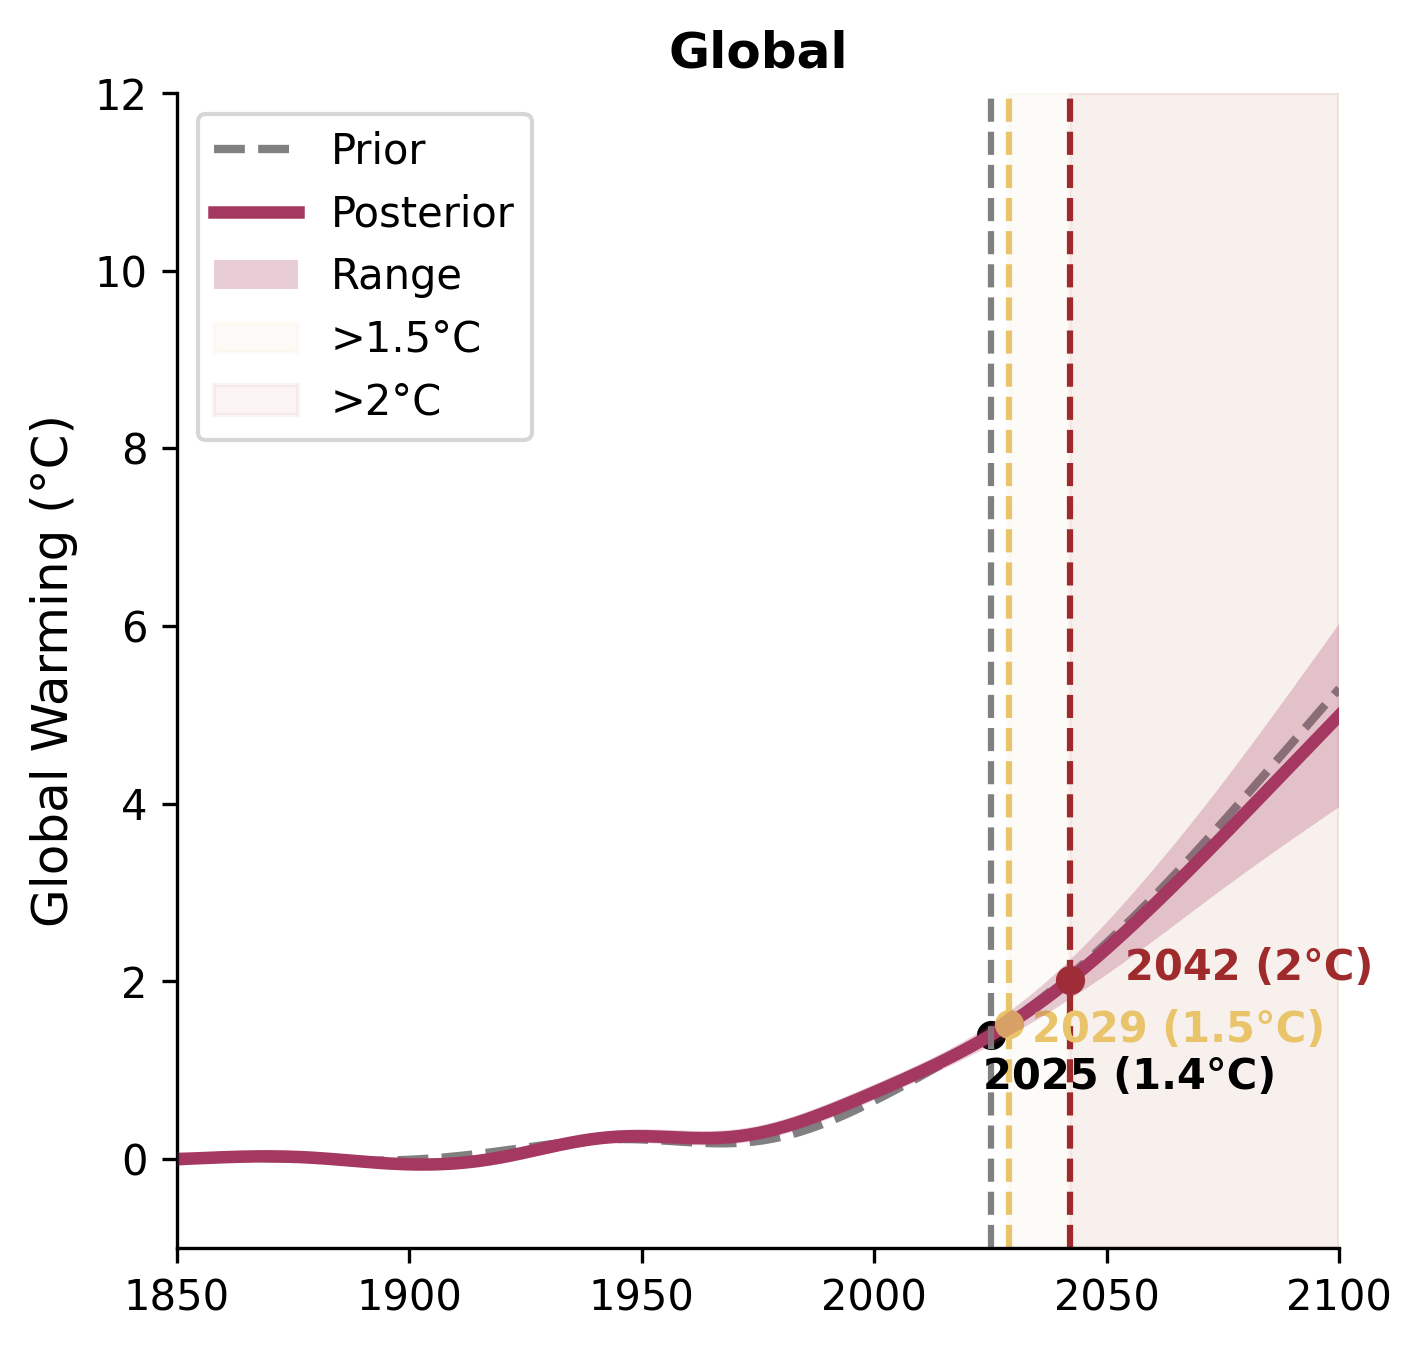

In [62]:

fig, ax = plt.subplots(1, 1, figsize=(5, 5
), dpi=300, sharey=True)

plt.plot(prior_gsat_ref18['year'], prior_gsat_ref18, label = 'Prior', color = 'gray', ls = '--', lw = 2)
plt.plot(post_gsat_ref18['year'], post_gsat_ref18, label = 'Posterior', color = '#a53860', ls = '-', lw = 3)

# plot_shading(ax, prior_warm_5_95['year'], prior_warm_5_95.sel(quantile = '5th'),prior_warm_5_95.sel(quantile = '95th'), label = 'Posterior', color = 'gray', ls = '-', lw = 3)

plot_shading(ax, post_warm_5_95['year'], post_warm_5_95.sel(quantile = '5th'),post_warm_5_95.sel(quantile = '95th'), label = 'Range', color = '#a53860', alpha= 0.25)

color_15 = '#e9c46a'
color_2 = '#9e2a2b'
# Shade time period after 1.5°C
ax.axvspan(gsat_15_post, 2100, color= color_15, alpha=0.05, label='>1.5°C')

# Shade time period after 2°C
ax.axvspan(gsat_2_post, 2100, color= color_2, alpha=0.05, label='>2°C')


ax.axvline(gsat_15_post, color= color_15, ls='--', lw=1.5)
ax.axvline(gsat_2_post, color= color_2, ls='--', lw=1.5)

ax.axvline(current_year, color='gray', ls='--', lw=1.5)

# ---- Label 1.5°C ----
y15 = post_gsat_ref18.sel(year=gsat_15_post)
ax.text(gsat_15_post + 5, y15 - 0.2,
        f"{gsat_15_post} (1.5°C)",
        color= color_15, ha='left', weight = 'bold', fontsize=10)

# ---- Label 2°C ----
y2 = post_gsat_ref18.sel(year=gsat_2_post)
ax.text(gsat_2_post + 12, y2 + 0.,
        f"{gsat_2_post} (2°C)",
        color= color_2, ha='left', weight = 'bold', fontsize=10)

# ---- Label current year ----
y_curr = post_gsat_ref18.sel(year=current_year)
ax.scatter(current_year, y_curr, color='black')
ax.text(current_year + 30 , y_curr - 0.6,
        f"{current_year} (1.4°C)",
        color='black', ha='center', weight = 'bold', fontsize=10)

ax.scatter(gsat_15_post, y15, color=color_15, zorder = 20)
ax.scatter(gsat_2_post, y2, color=color_2, zorder = 20)

ax.set_ylabel("Global Warming (°C)", fontsize=12)

plt.xlim(1850, 2100)
plt.ylim(-1, 12)
plt.title('Global', weight = 'bold')
plt.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

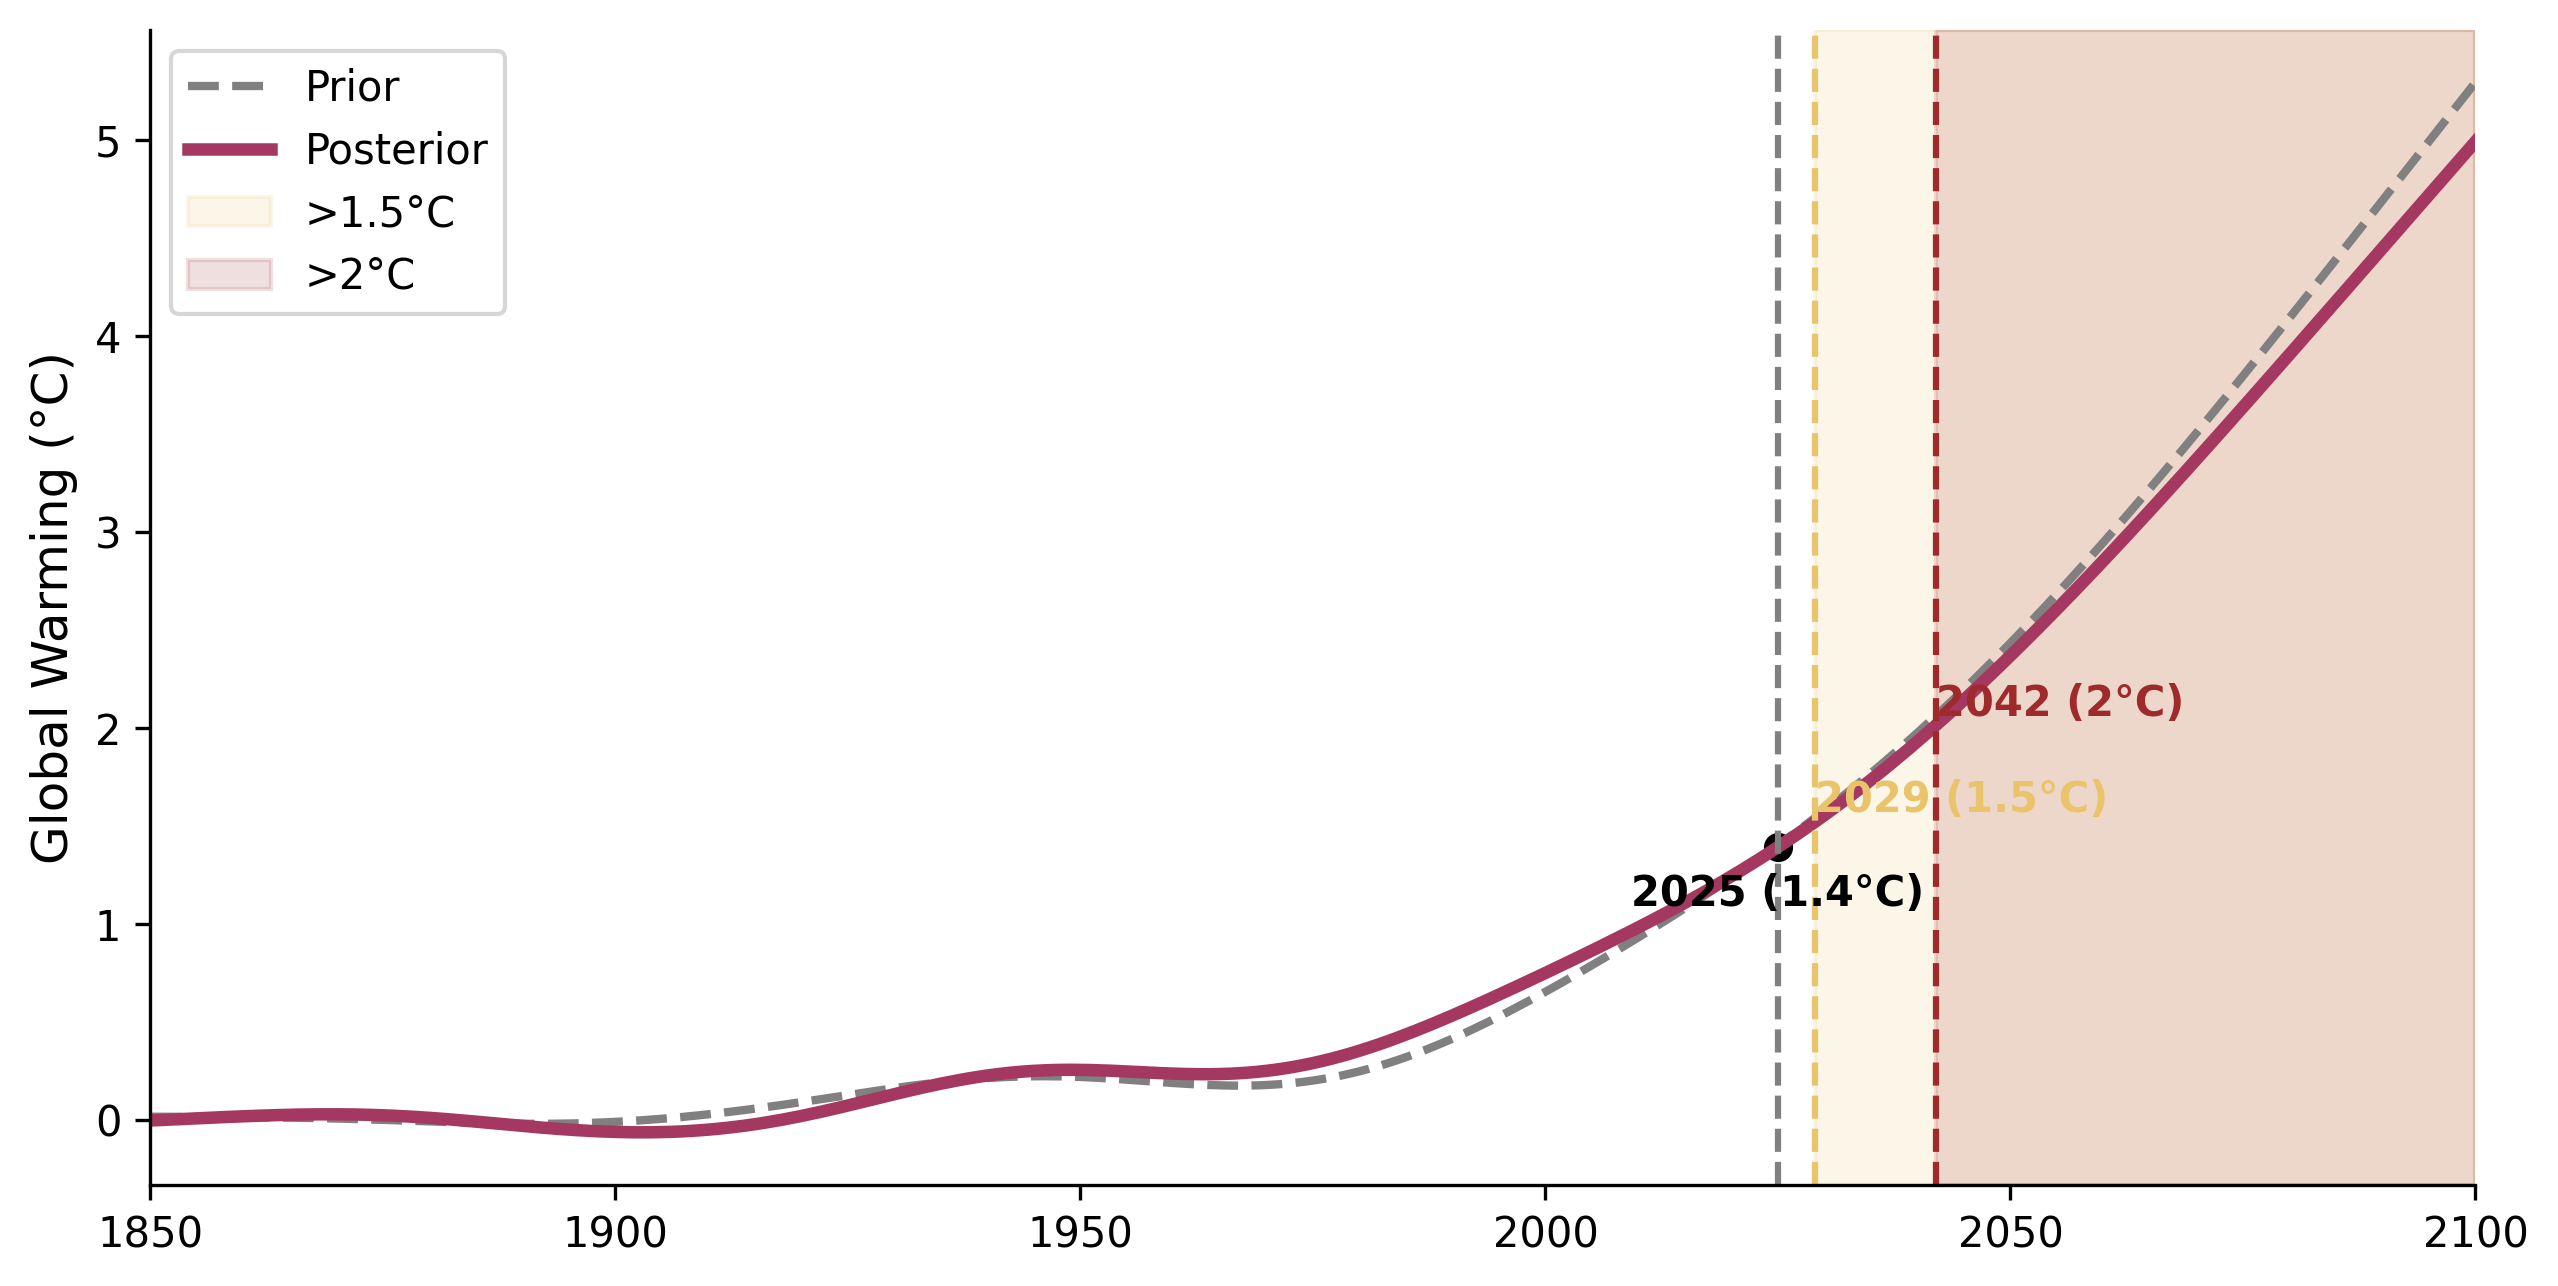

In [63]:

fig, ax = plt.subplots(1, 1, figsize=(10, 5
), dpi=300, sharey=True)

plt.plot(prior_gsat_ref18['year'], prior_gsat_ref18, label = 'Prior', color = 'gray', ls = '--', lw = 2)
plt.plot(post_gsat_ref18['year'], post_gsat_ref18, label = 'Posterior', color = '#a53860', ls = '-', lw = 3)



color_15 = '#e9c46a'
color_2 = '#9e2a2b'
# Shade time period after 1.5°C
ax.axvspan(gsat_15_post, 2100, color= color_15, alpha=0.15, label='>1.5°C')

# Shade time period after 2°C
ax.axvspan(gsat_2_post, 2100, color= color_2, alpha=0.15, label='>2°C')


ax.axvline(gsat_15_post, color= color_15, ls='--', lw=1.5)
ax.axvline(gsat_2_post, color= color_2, ls='--', lw=1.5)

ax.axvline(current_year, color='gray', ls='--', lw=1.5)

# ---- Label 1.5°C ----
y15 = post_gsat_ref18.sel(year=gsat_15_post)
ax.text(gsat_15_post, y15 + 0.05,
        f"{gsat_15_post} (1.5°C)",
        color= color_15, ha='left', weight = 'bold', fontsize=10)

# ---- Label 2°C ----
y2 = post_gsat_ref18.sel(year=gsat_2_post)
ax.text(gsat_2_post, y2 + 0.05,
        f"{gsat_2_post} (2°C)",
        color= color_2, ha='left', weight = 'bold', fontsize=10)

# ---- Label current year ----
y_curr = post_gsat_ref18.sel(year=current_year)
ax.scatter(current_year, y_curr, color='black')
ax.text(current_year, y_curr - 0.3,
        f"{current_year} (1.4°C)",
        color='black', ha='center', weight = 'bold', fontsize=10)

ax.set_ylabel("Global Warming (°C)", fontsize=12)

plt.xlim(1850, 2100)
plt.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
fig.savefig('./saved_figures/ED_Fig3.pdf', dpi=300, bbox_inches='tight')


### Load the regional, global land constraint results

### Constrained warming relative to current year 2025

In [64]:
path = './saved_data/'

def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)
        
post_smooth_ALL_ref2025 = load_xr_pickle(path + '2.2_constrained_46reg_lsat_smoothed_warming_ref2025_1850-2100.pkl')
post_smooth_ALL_ref1850 = load_xr_pickle(path + '2.3_constrained_46reg_lsat_smoothed_warming_ref1850_1850-2100.pkl')


In [65]:
post_warming_15_ref2025 = post_smooth_ALL_ref2025.sel(year = slice(gsat_15_post-5, gsat_15_post+5)).mean('year').squeeze()
post_warming_2_ref2025 = post_smooth_ALL_ref2025.sel(year = slice(gsat_2_post-5, gsat_2_post+5)).mean('year').squeeze()

post_warming_15_ref2025

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47, quantile: 3)> Size: 1kB
array([[ 0.21018108, -0.60626684,  1.1218199 ],
       [ 0.2680598 , -0.46882404,  0.93076403],
       [ 0.29212572, -0.36204089,  0.98000125],
       [ 0.17424656, -0.19206504,  0.46499116],
       [ 0.18374452, -0.19312368,  0.57512905],
       [ 0.18200525, -0.11884552,  0.45246206],
       [ 0.15975007, -0.06426394,  0.42587819],
       [ 0.12973921, -0.06227645,  0.31551045],
       [ 0.11453473, -0.05133803,  0.27000866],
       [ 0.13361265, -0.17839936,  0.39909889],
       [ 0.16697142, -0.26425736,  0.56364035],
       [ 0.14061217, -0.15489513,  0.38333276],
       [ 0.18991347, -0.26159952,  0.54455802],
       [ 0.11985369, -0.11433889,  0.43223791],
       [ 0.12078172, -0.09815737,  0.35604384],
       [ 0.07905102, -0.10248476,  0.31368722],
       [ 0.16475769, -0.36275174,  0.62682949],
       [ 0.22274343, -0.17177542,  0.66684671],
       [ 0.24923262, -0.24325528,  0.82625337],
       [ 0.17239277, -0.13535223,  0.43211364],
...
       [ 0.12695027, -0.07570015,  0.32029323],
       [ 0.3400744 , -0.56241397,  1.33333612],
       [ 0.26124435, -0.28264962,  0.8253559 ],
       [ 0.27429078, -0.23326657,  0.74868227],
       [ 0.20935638, -0.35497859,  0.72987464],
       [ 0.20630692, -0.16034355,  0.58448221],
       [ 0.20797804, -0.22544121,  0.56758331],
       [ 0.20517805, -0.22632642,  0.64030781],
       [ 0.19705066, -0.08015466,  0.46320771],
       [ 0.20068772, -0.11880345,  0.4591364 ],
       [ 0.15150357, -0.15165275,  0.37279178],
       [ 0.11362119, -0.08689435,  0.29176218],
       [ 0.11744662, -0.08816877,  0.3561919 ],
       [ 0.15931373, -0.18766831,  0.47830672],
       [ 0.1473007 , -0.12939425,  0.34412464],
       [ 0.07615089, -0.14492939,  0.30165412],
       [ 0.10887216, -0.12521428,  0.33105177],
       [ 0.14160127, -0.46532871,  0.68570889],
       [ 0.1379566 , -0.68622335,  0.95448602],
       [ 0.1693419 , -0.1338757 ,  0.47682958]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    forcing      <U3 12B 'ALL'
  * quantile     (quantile) <U4 48B 'mean' '5th' '95th'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100

In [66]:
current_yr = 2025
post_warming_current_year = post_smooth_ALL_ref1850.sel(year = current_yr, quantile = 'mean').squeeze()

percent_nowaday_15 = (post_warming_current_year / (post_warming_current_year + post_warming_15_ref2025)) * 100
percent_nowaday_2 = (post_warming_current_year / (post_warming_current_year + post_warming_2_ref2025)) * 100


## switch 5, 95th, cause it is on denorminator
percent_nowaday_15 = percent_nowaday_15.rename({'quantile': 'quantile'})
percent_nowaday_15 = percent_nowaday_15.assign_coords(
    quantile=['95th' if q == '5th' else '5th' if q == '95th' else q for q in percent_nowaday_15['quantile'].values]
)

percent_nowaday_2 = percent_nowaday_2.rename({'quantile': 'quantile'})
percent_nowaday_2 = percent_nowaday_2.assign_coords(
    quantile=['95th' if q == '5th' else '5th' if q == '95th' else q for q in percent_nowaday_2['quantile'].values]
)
percent_nowaday_15

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47, quantile: 3)> Size: 1kB
array([[ 92.48561154, 130.61025362,  69.75156358],
       [ 91.68199259, 118.86038575,  76.04425988],
       [ 91.8389268 , 112.37605012,  77.03504335],
       [ 91.63678516, 111.18493533,  80.41509458],
       [ 91.97399238, 110.09799313,  78.54595169],
       [ 91.33826684, 106.60104006,  80.922567  ],
       [ 91.17439235, 104.05179654,  79.48763764],
       [ 91.13025965, 104.90095073,  80.8606193 ],
       [ 91.47834804, 104.3574344 ,  81.99363257],
       [ 91.52604215, 114.10570164,  78.3361049 ],
       [ 90.48855894, 119.95523272,  73.81034311],
       [ 92.61204973, 109.6342411 ,  82.13720543],
       [ 90.30239647, 117.3607833 ,  76.45662767],
       [ 90.17689598, 111.59708581,  71.79532675],
       [ 92.28495134, 107.28930181,  80.22853234],
       [ 92.54336718, 111.66444762,  75.77293024],
       [ 92.70304098, 120.96363368,  76.95451857],
       [ 91.27645471, 107.95683817,  77.75295797],
       [ 91.17037517, 110.43925165,  75.696337  ],
       [ 91.44081922, 107.93211739,  80.99637009],
...
       [ 90.89484108, 106.35272462,  79.8254515 ],
       [ 92.15600591, 116.38264395,  74.97838243],
       [ 90.71230235, 112.45752905,  75.55885269],
       [ 91.13546374, 109.01795225,  79.02051578],
       [ 91.56143057, 118.52115609,  75.68271734],
       [ 91.69338874, 107.57410479,  79.57657375],
       [ 91.24911642, 111.60134932,  79.2569458 ],
       [ 91.94686871, 110.69443869,  78.53429781],
       [ 90.52247695, 104.44826382,  80.24948028],
       [ 91.46456442, 105.84737821,  82.40640116],
       [ 90.99398662, 110.99656024,  80.41583943],
       [ 91.7499546 , 107.38455823,  81.24150142],
       [ 91.63457652, 107.35758993,  78.31665831],
       [ 91.32310875, 112.60290933,  77.80543366],
       [ 91.76257567, 108.56068651,  82.66385778],
       [ 94.10067494, 113.54783604,  80.10648377],
       [ 91.64591605, 111.71174438,  78.29738535],
       [ 91.65705664, 142.67786739,  69.40664602],
       [ 92.11424766, 174.16535768,  62.80214606],
       [ 91.7560112 , 107.6460715 ,  79.80916117]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100
  * quantile     (quantile) <U4 48B 'mean' '95th' '5th'

### Map plotting

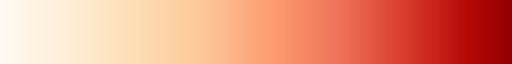

In [67]:
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap


# cmap_percent = modify_cmap('twilight', start=0.0, end=0.9, gamma=1.0, white_strength=0.7)   # example: different color map
# bounds2 = np.arange(50, 110, 10)  # example levels
# norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=256, extend='neither')

# n_colors = len(bounds2) - 1  # = 5

# # Get discrete colors from the colormap
# colors_n = [cmap_percent(i / (n_colors - 1)) for i in range(n_colors)]

# # Swap the 5th color into 3rd position
# # Note: Python is 0-based -> 5th = index 4, 3rd = index 2
# colors_n[2], colors_n[4] = colors_n[4], colors_n[2]

# # Create a new colormap with the modified order
# cmap_percent = mcolors.ListedColormap(colors_n)

# # Recreate the norm
# norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=cmap_percent.N, extend='neither')

 
cmap_percent = modify_cmap('OrRd', start=0.0, end=0.95, gamma=1.0, white_strength=0.3)
bounds2 = np.arange(50, 110, 10)  # 50, 60, 70, 80, 90, 100, 110
norm2 = mcolors.BoundaryNorm(boundaries=bounds2, ncolors=256, extend='neither')

cmap_percent

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_13303/132762987.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


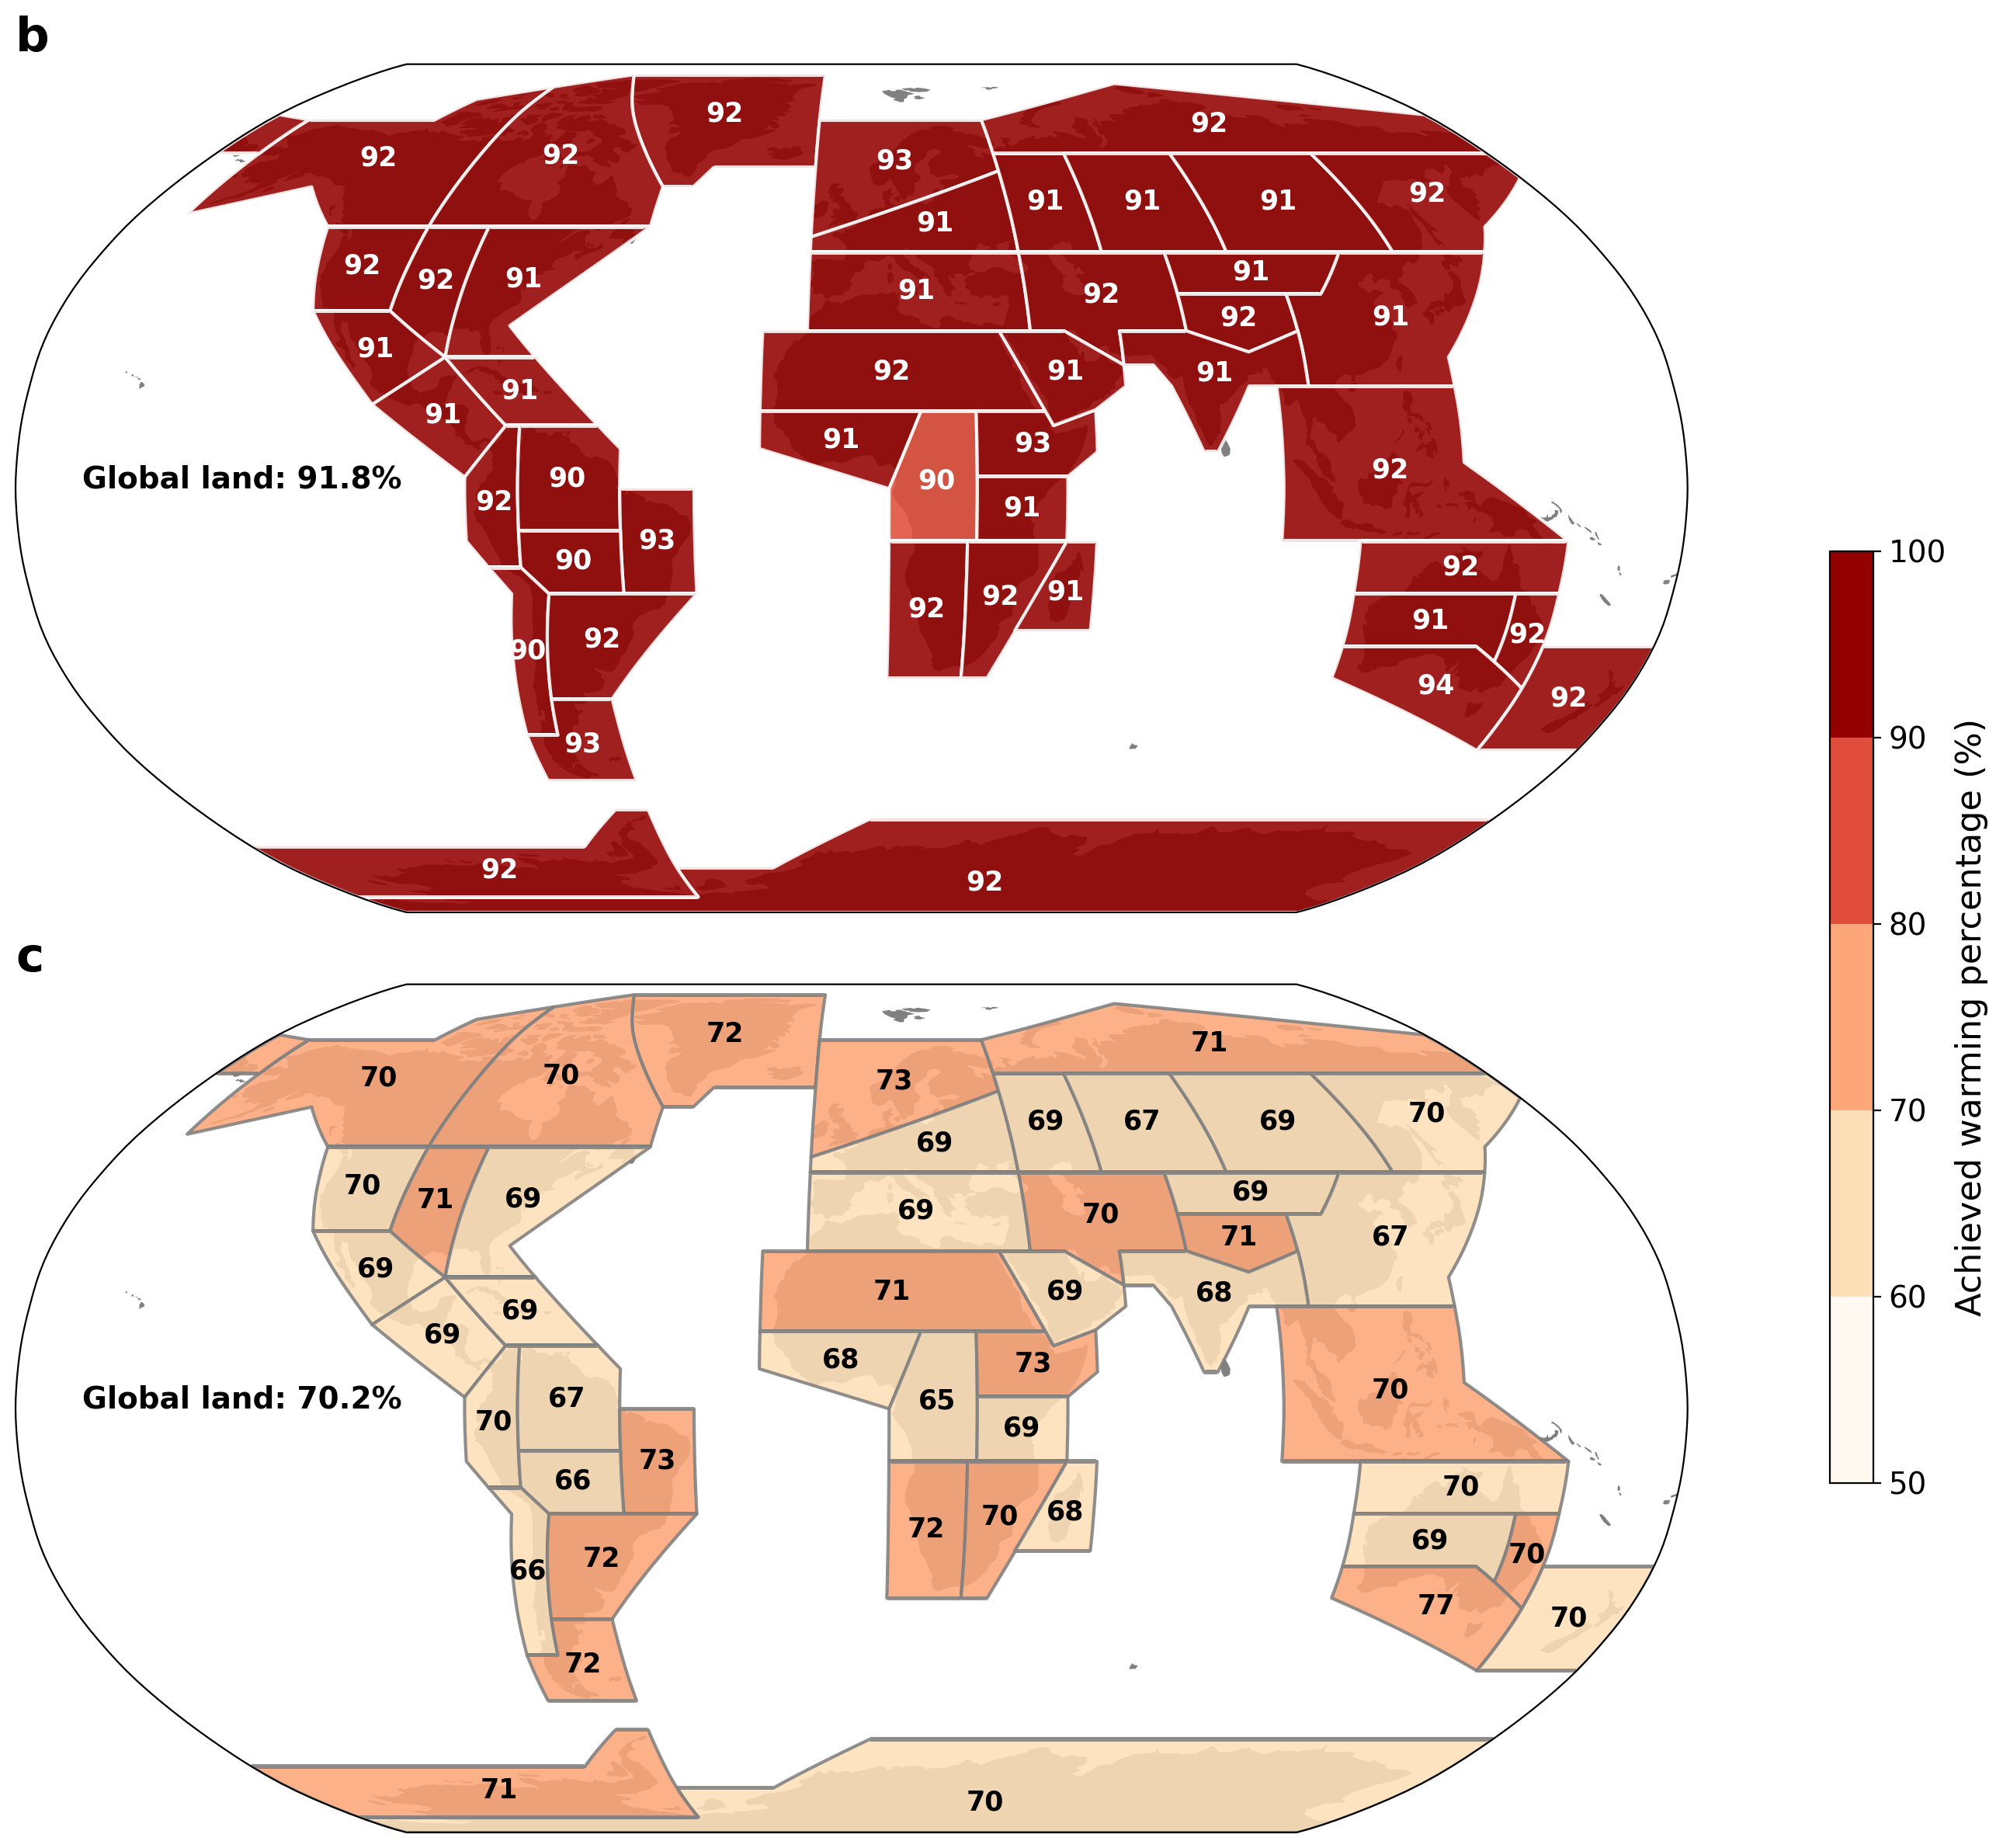

In [68]:
def plot_panel(ax, data, title, cmap, norm, decimals,
               global_value=None, unit="°C"):
    
    ax.set_global()
    norm0 = plot_ar6_region_data_on_ax_new(
        ax, data, cmap=cmap, norm=norm, decimals=decimals
    )

    # ---- Add title ----
    ax.set_title(title, fontsize=22, fontweight='bold', loc='left')

    # ---- Add the global value with a unit ----
    if global_value is not None:
        ax.text(
            0.04, 0.5,
            f"Global land: {global_value:.1f}{unit}",   # unit inserted here
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=4)
        )

    return norm0

# ---- Data dictionary ----
# data_dict = {
#     "(b) Nowadays to 1.5°C": percent_nowaday_15.sel(quantile = 'mean'),     # existing data
#     "(c) Nowadays to 2°C": percent_nowaday_2.sel(quantile = 'mean')    # add your second data array here
# }

data_dict = {
    "b": percent_nowaday_15.isel(region = slice(0,46)).sel(quantile = 'mean'),     # existing data
    "c": percent_nowaday_2.isel(region = slice(0,46)).sel(quantile = 'mean')    # add your second data array here
}

global_15 = percent_nowaday_15.where(percent_nowaday_15.abbrevs == 'LSAT', drop=True).sel(quantile = 'mean').values.item()
global_2 = percent_nowaday_2.where(percent_nowaday_2.abbrevs == 'LSAT', drop=True).sel(quantile = 'mean').values.item()

global_values = {
    "b": global_15,
    "c": global_2
}

# ---- Plot 2 panels ----
fig, axes = plt.subplots(2, 1, figsize=(14, 12), subplot_kw={'projection': ccrs.Robinson()}, dpi=200)

for ax, (label, data) in zip(axes, data_dict.items()):
    plot_panel(ax, data, f"{label}", cmap_percent, norm2, decimals = 0, global_value=global_values[label], unit = '%')

# ---- Shared colorbar ----
sm = mpl.cm.ScalarMappable(cmap=cmap_percent, norm=norm2)
sm.set_array([])

# [left, bottom, width, height] in figure coordinates (0–1)
cbar_ax = fig.add_axes([0.95, 0.2, 0.02, 0.5])  
cb = fig.colorbar(sm, cax=cbar_ax)
cb.ax.tick_params(labelsize=14)
cb.set_label("Achieved warming percentage (%)", fontsize=16)

plt.tight_layout()
plt.show()
fig.savefig('./saved_figures/Fig_1b-c.pdf', dpi=300, bbox_inches='tight')


In [69]:
from PIL import Image
from pdf2image import convert_from_path
import os

# Paths to your PDFs
pdf_1a = './saved_figures/Fig_1a.pdf'  # Update path if needed
pdf_1bc = './saved_figures/Fig_1b-c.pdf'  # Update path if needed
output_pdf = './saved_figures/Fig_1_combined.pdf'

# pdf2image requires Poppler's command-line tools. Jupyter kernels may not
# inherit Homebrew's bin directory, so locate it explicitly on macOS.
poppler_path = next((path for path in ('/opt/homebrew/bin', '/usr/local/bin')
                     if os.path.isfile(os.path.join(path, 'pdfinfo'))), None)
if poppler_path is None:
    raise RuntimeError('Poppler was not found. Install it with: brew install poppler')

# Convert PDFs to images
print("Converting PDFs to images...")
images_1a = convert_from_path(pdf_1a, dpi=300, poppler_path=poppler_path)
images_1bc = convert_from_path(pdf_1bc, dpi=300, poppler_path=poppler_path)

# Get the first page of each (assuming single-page PDFs)
img_1a = images_1a[0]
img_1bc = images_1bc[0]

# Get dimensions
w_1a, h_1a = img_1a.size
w_1bc, h_1bc = img_1bc.size

# Resize to same height for side-by-side layout
# Keep aspect ratio, resize to max height
max_height = max(h_1a, h_1bc)
scale_1a = max_height / h_1a
scale_1bc = max_height / h_1bc

img_1a = img_1a.resize((int(w_1a * scale_1a), max_height), Image.Resampling.LANCZOS)
img_1bc = img_1bc.resize((int(w_1bc * scale_1bc), max_height), Image.Resampling.LANCZOS)

# Create new image with both side-by-side (with small margin)
margin = 20
total_width = img_1a.width + img_1bc.width + margin
total_height = max_height

combined = Image.new('RGB', (total_width, total_height), color='white')

# Paste images
combined.paste(img_1a, (0, 0))
combined.paste(img_1bc, (img_1a.width + margin, 0))

# Save as PDF
combined.convert('RGB').save(output_pdf, 'PDF', quality=95)
print(f"Combined figure saved to: {output_pdf}")


Converting PDFs to images...
Combined figure saved to: ./saved_figures/Fig_1_combined.pdf


In [70]:
post_warming_current_year

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47)> Size: 376B
array([2.58686734, 2.95458464, 3.28737562, 1.90924119, 2.10561933,
       1.91925147, 1.65032436, 1.33297786, 1.22950901, 1.44313165,
       1.58850832, 1.76265151, 1.7684412 , 1.10026667, 1.44475237,
       0.98109265, 2.09313751, 2.33061563, 2.57345377, 1.84173426,
       2.13433499, 1.6416944 , 1.2248822 , 1.90831206, 1.49828075,
       1.83105185, 1.64629037, 1.26731719, 3.99540058, 2.55155555,
       2.81995774, 2.27159   , 2.27734032, 2.16867386, 2.34262656,
       1.88208607, 2.15054228, 1.53074541, 1.2635978 , 1.28650648,
       1.67675552, 1.64088816, 1.2146898 , 1.19434861, 1.55565665,
       1.61148464, 1.88478394])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_13303/235690464.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


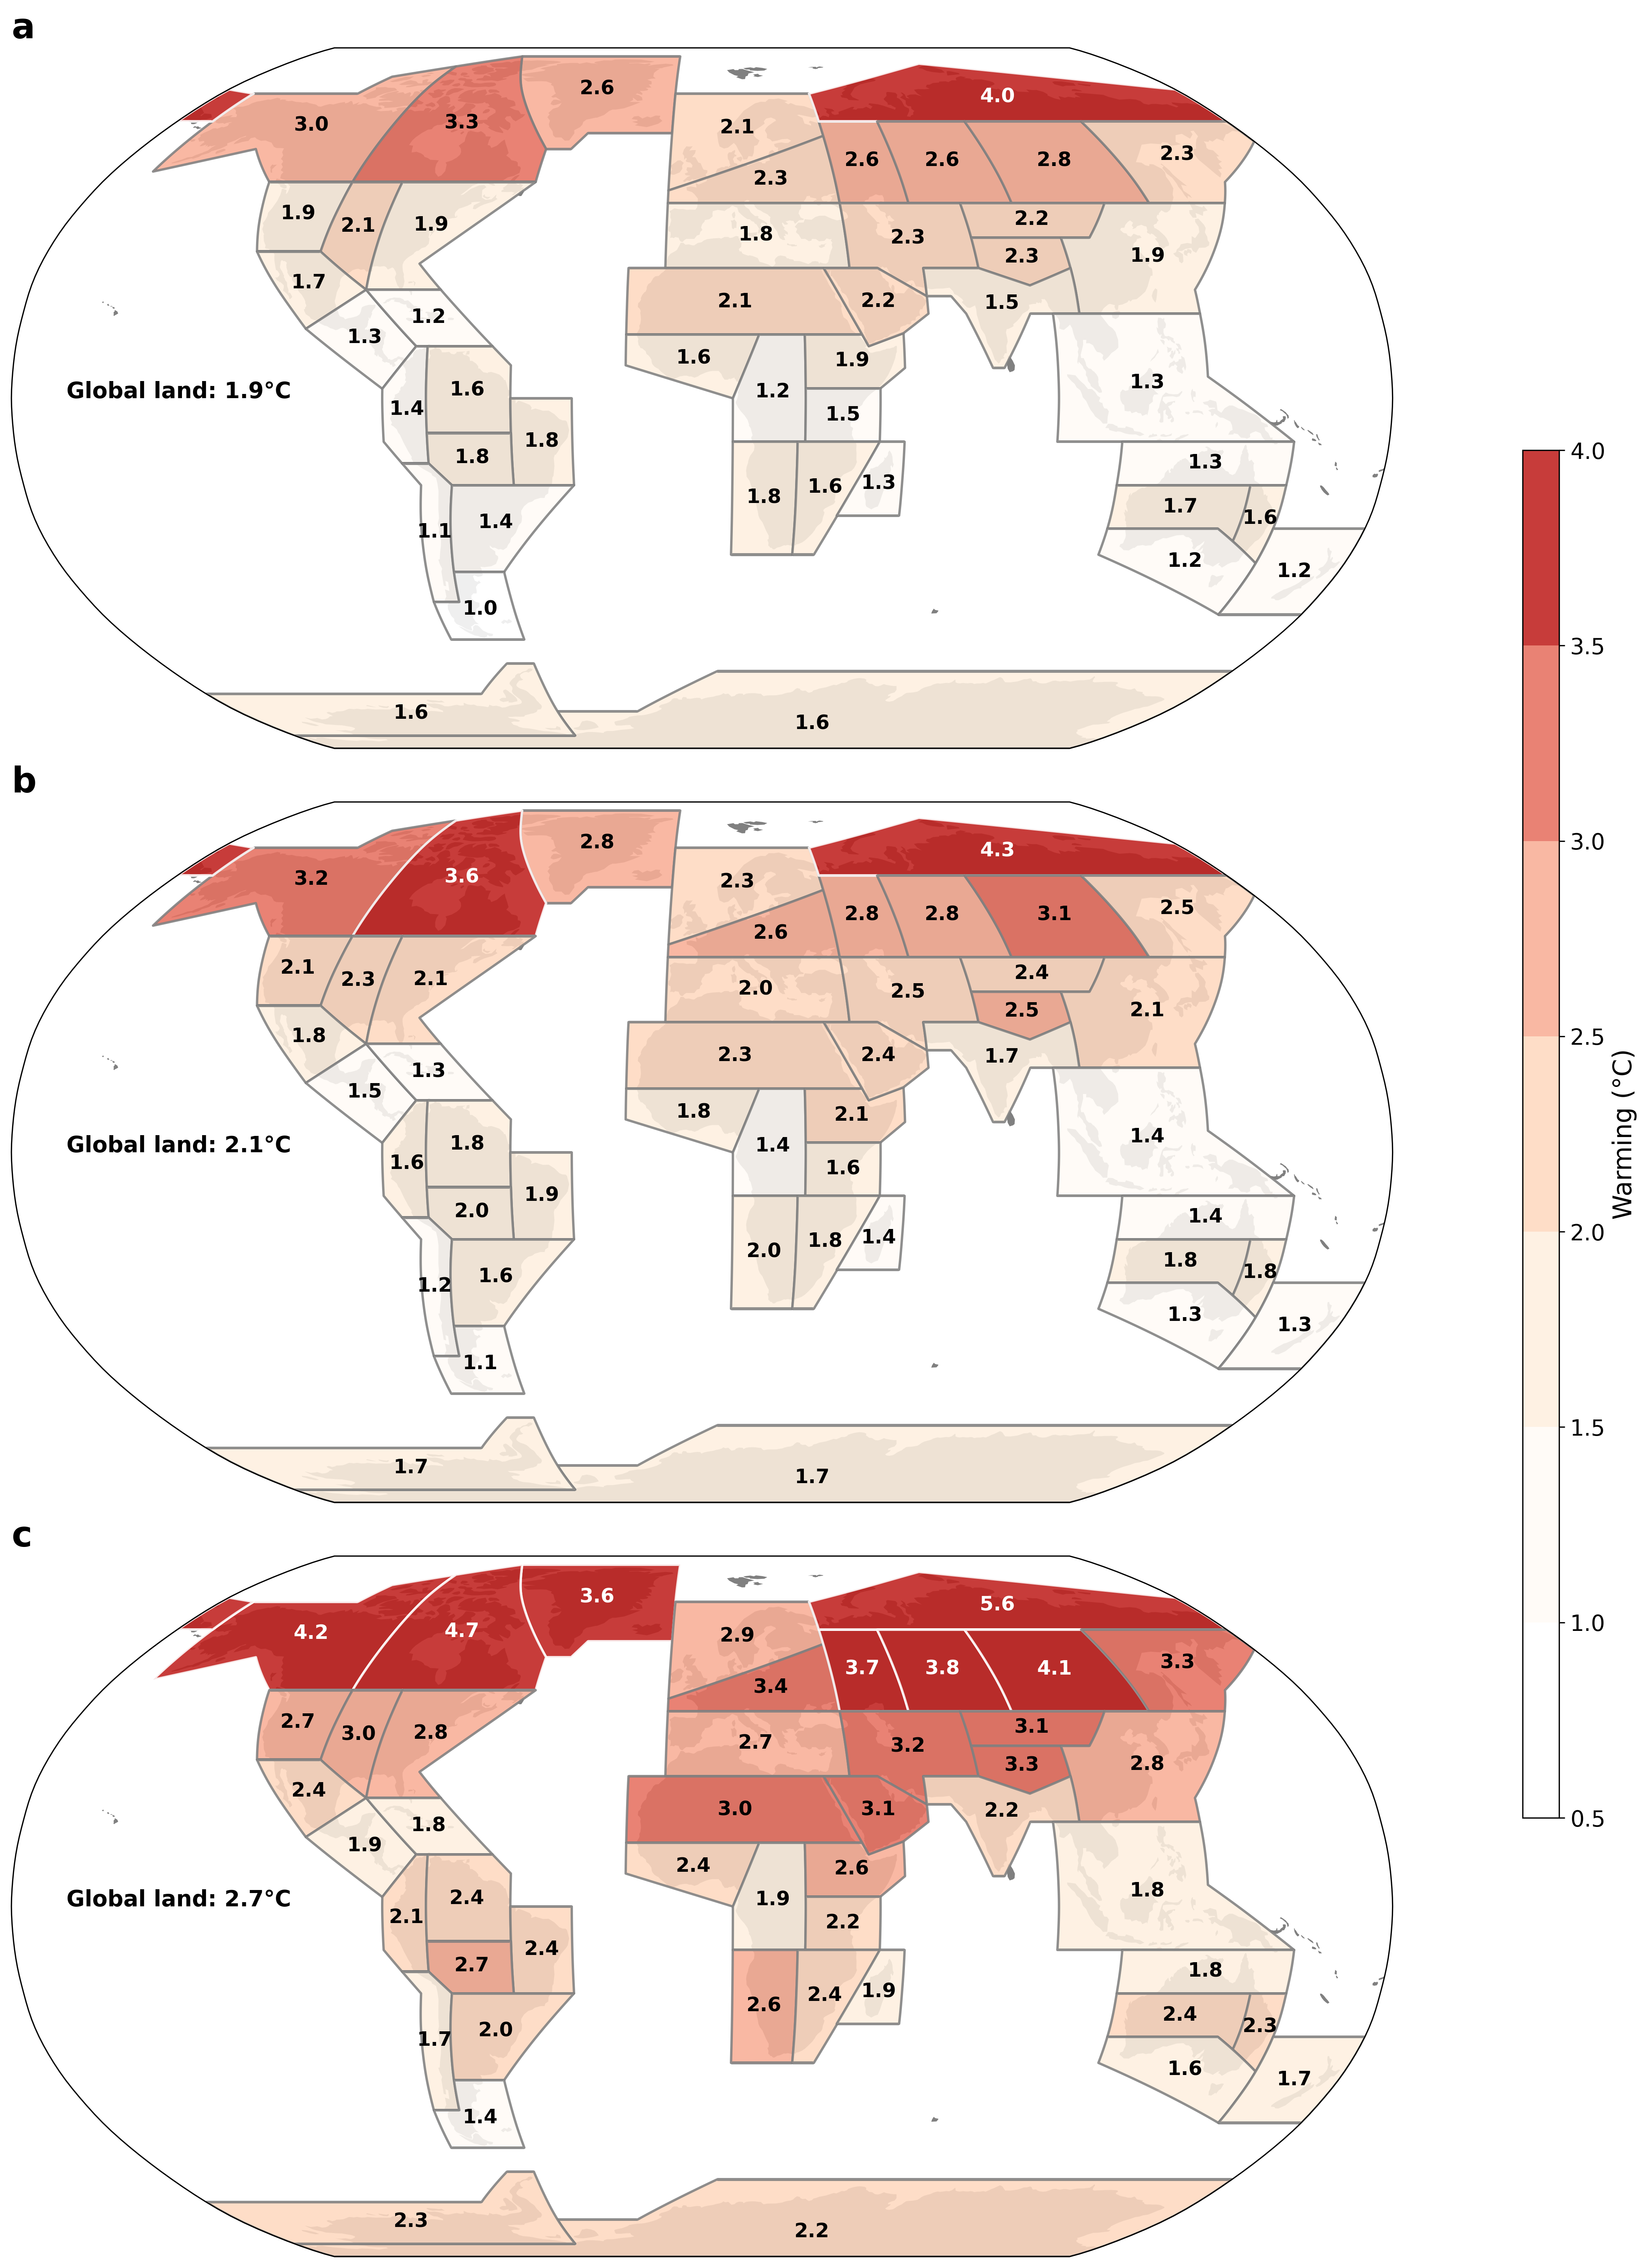

In [71]:
def set_cmap_alpha(cmap, alpha=1.0):
    colors = cmap(np.arange(cmap.N))
    colors[:, -1] = alpha
    return mpl.colors.ListedColormap(colors)

cmap = modify_cmap('OrRd', start=0.0, end=0.95, gamma=1.0, white_strength=1.0)
colors_array = cmap(np.linspace(0, 1, 256))
truncated_colors = colors_array[:230]
truncated_cmap = mcolors.LinearSegmentedColormap.from_list('truncated_YlOrBr', truncated_colors)
cmap_with_alpha = set_cmap_alpha(truncated_cmap, alpha=0.88)


# ---- Data dictionary ----
# data_dict = {
#     "1.5°C Warming world": post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year,
#     "2°C Warming world": post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year    # add your second data array here
# }

data_current = post_warming_current_year.isel(region = slice(0, 46))
data_15 = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(0, 46))
data_2 = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(0, 46))

data_dict = {
    "a": data_current,
    "b": data_15,
    "c": data_2
}

global_current = post_warming_current_year.where(post_warming_current_year.abbrevs == 'LSAT', drop=True).values.item()

global_15 = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year).where(post_warming_15_ref2025.abbrevs == 'LSAT', drop=True).values.item()

global_2 = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year).where(post_warming_2_ref2025.abbrevs == 'LSAT', drop=True).values.item()

global_values = {
    "a": global_current,
    "b": global_15,
    "c": global_2
}

bounds = np.arange(0.5, 4.5, 0.5)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

# ---- Plot 3 panels: current year, 1.5°C world, and 2°C world ----
fig, axes = plt.subplots(3, 1, figsize=(16, 20), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)
for ax, (label, data) in zip(axes, data_dict.items()):
    plot_panel(ax, data, f"{label}", cmap_with_alpha, norm, decimals = 1, global_value=global_values[label], unit = '°C')

# ---- Shared colorbar ----
sm = mpl.cm.ScalarMappable(cmap=cmap_with_alpha, norm=norm)
sm.set_array([])


# [left, bottom, width, height] in figure coordinates (0–1)
cbar_ax = fig.add_axes([0.95, 0.2, 0.02, 0.6])  
cb = fig.colorbar(sm, cax=cbar_ax)
cb.ax.tick_params(labelsize=14)
cb.set_label("Warming (°C)", fontsize=16)

plt.tight_layout()
plt.show()
fig.savefig('./saved_figures/ED_Fig4.pdf', dpi=300, bbox_inches='tight')


In [ ]:
40/56

0.7142857142857143

### Uncertainty

In [72]:
labels = post_warming_15_ref2025.coords['abbrevs'].values

groups = {
    'North and Central America': ['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR'],
    'South America': ['NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA'],
    'Europe': ['NEU', 'WCE', 'EEU', 'MED'],
    'Africa': ['SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG'],
    'Asia': ['RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS'],
    'Australasia': ['SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ'],
    'Antarctica': ['EAN', 'WAN'],
    'Global land': ['LSAT']
}

# Create a mapping from abbrev to index
abbrev_to_index = {abbr: i for i, abbr in enumerate(labels)}
continent_indices = {k: [abbrev_to_index[abbr] for abbr in v] for k, v in groups.items()}


colors = {
    'North and Central America': '#c45a5c',  # soft green
    'South America': '#a9b5da',               # lavender blue
    'Europe': '#f5a966',                      # warm yellow-orange
    'Africa': '#bab1a0',                      # muted red
    'Asia': '#b47955',                        # light blue
    'Australasia': '#6e9c6d',                 # forest green
    'Antarctica': '#5590B4',                   # brick red
    'Global land': '#dda15e'
}

uncertainty_ref_period=(1850, 2025)
ref_period=(1850, 1900)
obs_adjust_ref_period=(1961, 2023)
warming_target_period=(2016, 2025)

In [73]:
post_warming_15_ref2025

<xarray.DataArray 'post_mean_5_95_smooth' (region: 47, quantile: 3)> Size: 1kB
array([[ 0.21018108, -0.60626684,  1.1218199 ],
       [ 0.2680598 , -0.46882404,  0.93076403],
       [ 0.29212572, -0.36204089,  0.98000125],
       [ 0.17424656, -0.19206504,  0.46499116],
       [ 0.18374452, -0.19312368,  0.57512905],
       [ 0.18200525, -0.11884552,  0.45246206],
       [ 0.15975007, -0.06426394,  0.42587819],
       [ 0.12973921, -0.06227645,  0.31551045],
       [ 0.11453473, -0.05133803,  0.27000866],
       [ 0.13361265, -0.17839936,  0.39909889],
       [ 0.16697142, -0.26425736,  0.56364035],
       [ 0.14061217, -0.15489513,  0.38333276],
       [ 0.18991347, -0.26159952,  0.54455802],
       [ 0.11985369, -0.11433889,  0.43223791],
       [ 0.12078172, -0.09815737,  0.35604384],
       [ 0.07905102, -0.10248476,  0.31368722],
       [ 0.16475769, -0.36275174,  0.62682949],
       [ 0.22274343, -0.17177542,  0.66684671],
       [ 0.24923262, -0.24325528,  0.82625337],
       [ 0.17239277, -0.13535223,  0.43211364],
...
       [ 0.12695027, -0.07570015,  0.32029323],
       [ 0.3400744 , -0.56241397,  1.33333612],
       [ 0.26124435, -0.28264962,  0.8253559 ],
       [ 0.27429078, -0.23326657,  0.74868227],
       [ 0.20935638, -0.35497859,  0.72987464],
       [ 0.20630692, -0.16034355,  0.58448221],
       [ 0.20797804, -0.22544121,  0.56758331],
       [ 0.20517805, -0.22632642,  0.64030781],
       [ 0.19705066, -0.08015466,  0.46320771],
       [ 0.20068772, -0.11880345,  0.4591364 ],
       [ 0.15150357, -0.15165275,  0.37279178],
       [ 0.11362119, -0.08689435,  0.29176218],
       [ 0.11744662, -0.08816877,  0.3561919 ],
       [ 0.15931373, -0.18766831,  0.47830672],
       [ 0.1473007 , -0.12939425,  0.34412464],
       [ 0.07615089, -0.14492939,  0.30165412],
       [ 0.10887216, -0.12521428,  0.33105177],
       [ 0.14160127, -0.46532871,  0.68570889],
       [ 0.1379566 , -0.68622335,  0.95448602],
       [ 0.1693419 , -0.1338757 ,  0.47682958]])
Coordinates:
  * region       (region) int64 376B 0 1 2 3 4 5 6 7 ... 39 40 41 42 43 44 45 46
    forcing      <U3 12B 'ALL'
  * quantile     (quantile) <U4 48B 'mean' '5th' '95th'
    abbrevs      (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
    names        (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
    realization  int64 8B 100

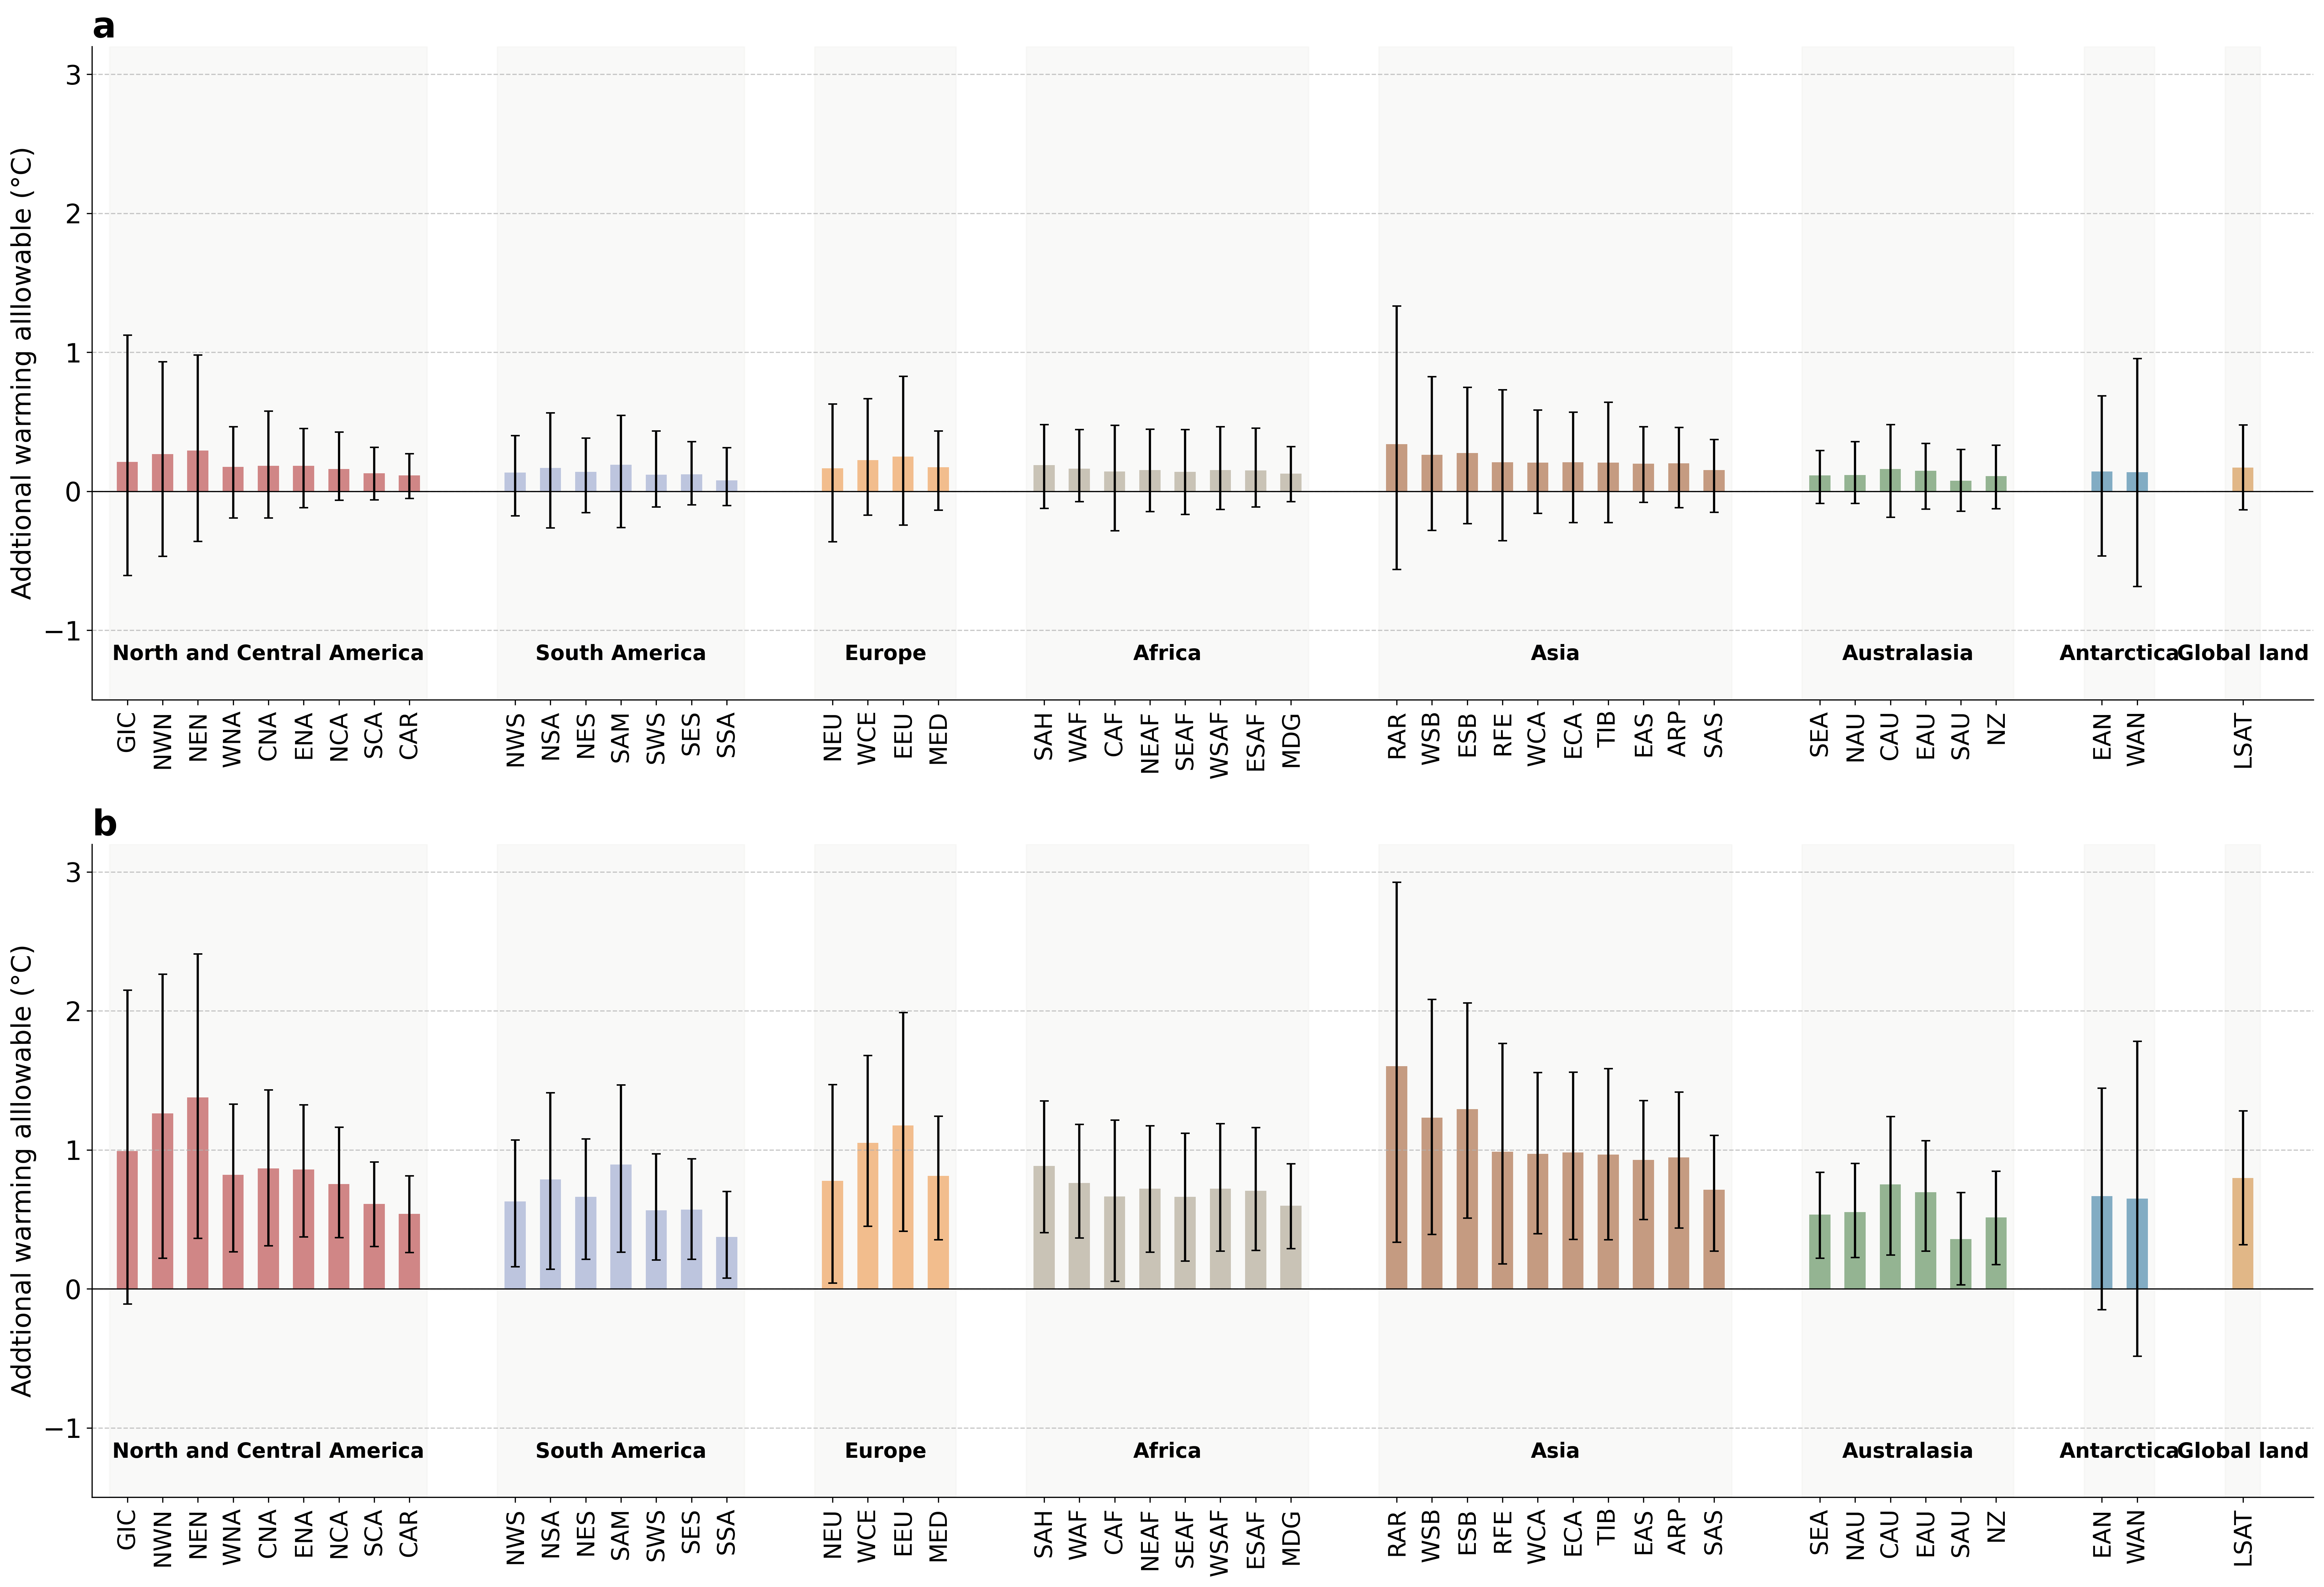

In [74]:
def plot_panel(ax, data, title, colors, continent_indices, labels, y_label, continent_height_value = -0.5, ylim_low = -1, ylim_high = 6, continent_label = 'True'):
    mean = data.sel(quantile='mean')
    err_lower = mean - data.sel(quantile='5th')
    err_upper = data.sel(quantile='95th') - mean

    bar_width = 0.6
    gap = 2

    x_ticks = []
    x_labels = []
    current_x = 0

    for continent, indices in continent_indices.items():
        for idx in indices:
            ax.bar(current_x, mean[idx], 
                   yerr=[[err_lower[idx]], [err_upper[idx]]],
                   color=colors[continent], capsize=3, alpha=1, width = bar_width)
            x_ticks.append(current_x)
            x_labels.append(labels[idx])
            current_x += 1
        current_x += gap

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90, fontsize=16)
    ax.set_ylabel(y_label, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_title(title, loc='left', fontsize=24, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)


    # Background and continent labels
    current_x = 0
    for continent, indices in continent_indices.items():
        group_width = len(indices)
        ax.axvspan(current_x - 0.5, current_x + group_width - 0.5, color='#edede9', alpha=0.3)
        group_center = current_x + group_width / 2 - 0.5

        if continent_label == 'True':
            ax.text(group_center, continent_height_value,
                    continent, ha='center', va='top', fontsize=14, fontweight='bold')
        current_x += group_width + gap

    ax.set_ylim(ylim_low, ylim_high)
    ax.set_xlim(-1, current_x - gap + 1)  # enforce same scaling

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

# Create the figure with two rows instead of one
fig, axs = plt.subplots(2, 1, figsize=(22, 15), dpi=300, sharey=True)

# Top panel
plot_panel(
    axs[0],
    post_warming_15_ref2025,
    # '(a) Nowadays to 1.5°C, Allowable Remaining warming (°C)',
    'a',
    colors,
    continent_indices,
    labels,
    'Addtional warming alllowable (°C)',
    continent_height_value=-1.1,  # lift up labels for tighter spacing
    ylim_low=-1.5,
    ylim_high=3.2
)

# Bottom panel
plot_panel(
    axs[1],
    post_warming_2_ref2025,
    # '(b) Nowadays to 2°C, Allowable Remaining Addtional warming alllowable (°C)',
    'b',
    colors,
    continent_indices,
    labels,
    'Addtional warming alllowable (°C)',
    continent_height_value=-1.1,
    ylim_low=-1.5,
    ylim_high=3.2
)

plt.tight_layout(h_pad=2.0)  # reduce vertical spacing between subplots
# main_title = f"(a) Attributable warming to ALL-forcing"
# fig.suptitle(main_title, fontsize=20, fontweight='bold', x = 0.63, y=1.02, ha = 'right')

plt.show()
fig.savefig('./saved_figures/ED_Fig6.pdf', dpi=300, bbox_inches='tight')


In [75]:
35*5

175

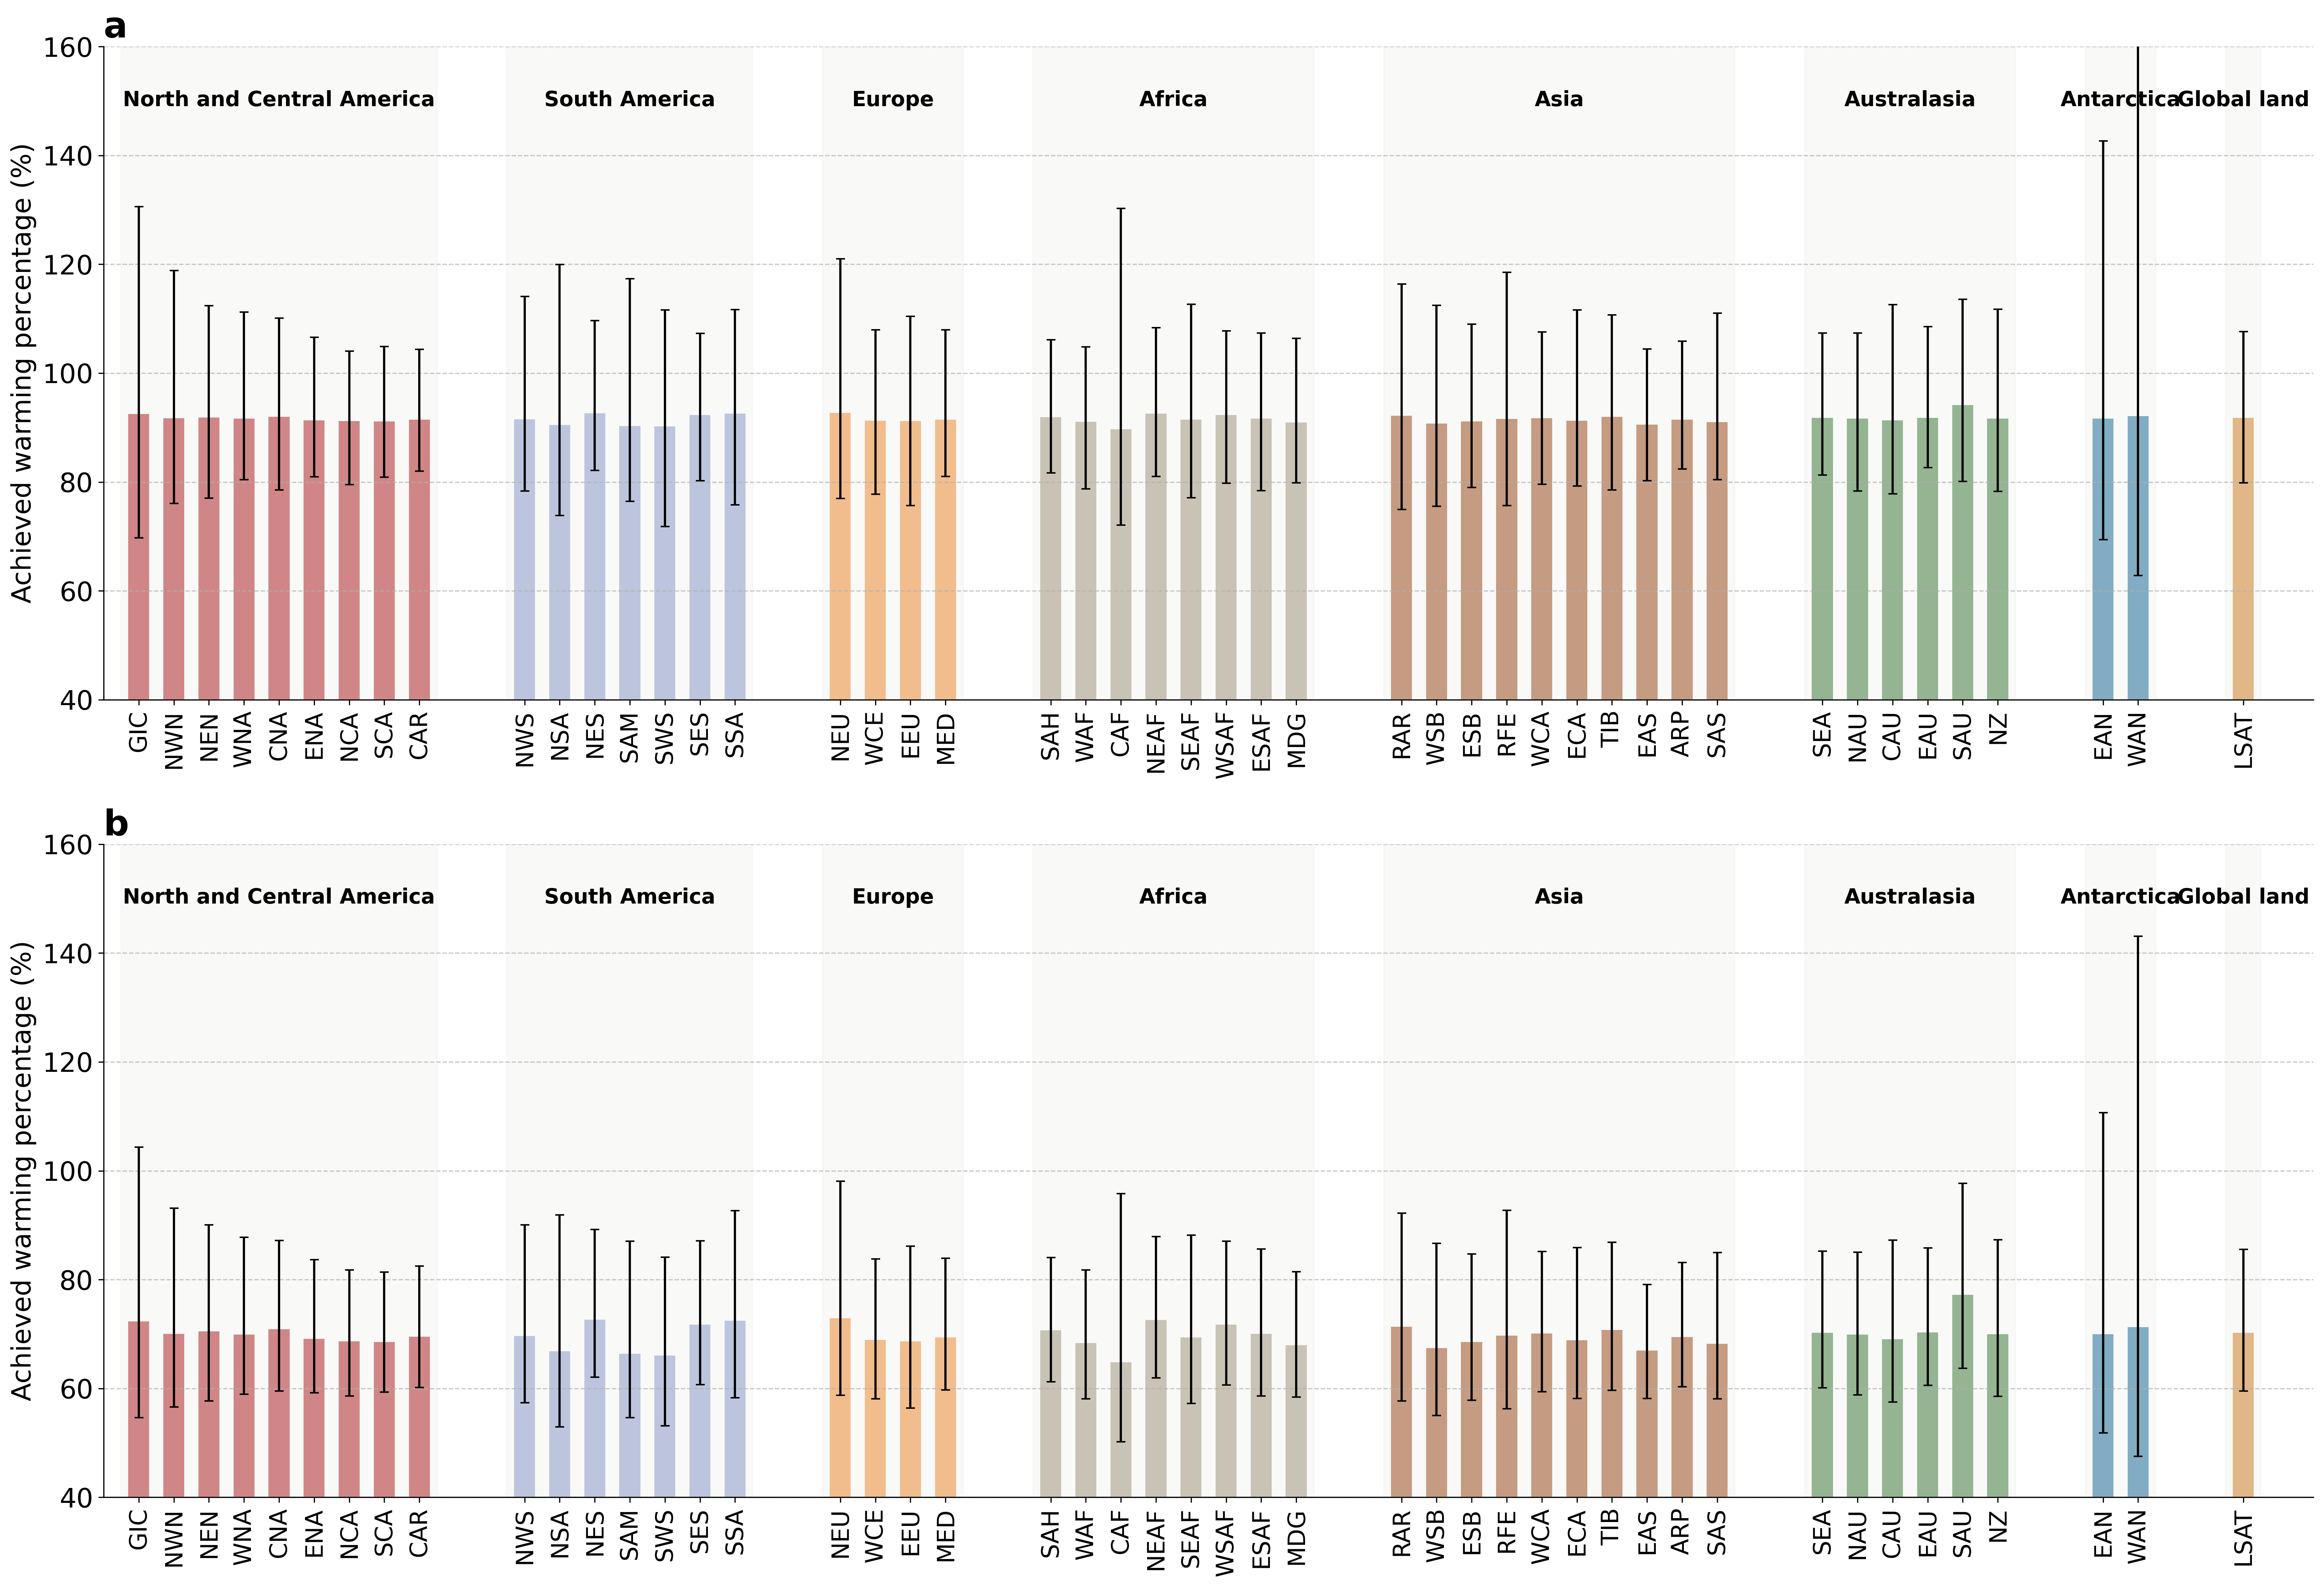

In [76]:

# Create the figure with two rows instead of one
fig, axs = plt.subplots(2, 1, figsize=(22, 15), dpi=300, sharey=True)

# Top panel
plot_panel(
    axs[0],
    percent_nowaday_15,
    # '(a) Nowadays to 1.5°C, Warming Occurred (%)',
    'a',
    colors,
    continent_indices,
    labels,
    'Achieved warming percentage (%)',
    continent_height_value=152,  # lift up labels for tighter spacing
    ylim_low=40,
    ylim_high=160
)

# Bottom panel
plot_panel(
    axs[1],
    percent_nowaday_2,
    # '(b) Nowadays to 2°C, Warming Occurred (%)',
    'b',
    colors,
    continent_indices,
    labels,
    'Achieved warming percentage (%)',
    continent_height_value=152,
    ylim_low=40,
    ylim_high=160
)

plt.tight_layout(h_pad=2.0)  # reduce vertical spacing between subplots
# main_title = f"(a) Attributable warming to ALL-forcing"
# fig.suptitle(main_title, fontsize=20, fontweight='bold', x = 0.63, y=1.02, ha = 'right')

plt.show()
fig.savefig('./saved_figures/ED_Fig5.pdf', dpi=300, bbox_inches='tight')


### AR6 region, area-mean-average

In [77]:
percent_reg_15 = percent_nowaday_15.sel(quantile = 'mean')
percent_reg_2 = percent_nowaday_2.sel(quantile = 'mean')
warming_reg_15 = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year)
warming_reg_2 = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year)


In [78]:
percent_reg_15_weighted_glob = compute_global_area_average(percent_reg_15)
percent_reg_2_weighted_glob = compute_global_area_average(percent_reg_2)

warming_reg_15_weighted_glob = compute_global_area_average(warming_reg_15)
warming_reg_2_weighted_glob = compute_global_area_average(warming_reg_2)

In [79]:
percent_15_constraint_glob = percent_nowaday_15.isel(region = slice(46, 47)).sel(quantile = 'mean')
percent_2_constraint_glob = percent_nowaday_2.isel(region = slice(46, 47)).sel(quantile = 'mean')

warming_15_constraint_glob = (post_warming_15_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(46, 47))
warming_2_constraint_glob = (post_warming_2_ref2025.sel(quantile = 'mean') + post_warming_current_year).isel(region = slice(46, 47))


In [80]:
print(warming_15_constraint_glob)
print(warming_reg_15_weighted_glob)

print(warming_2_constraint_glob)
print(warming_reg_2_weighted_glob)


<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([2.05412584])
Coordinates:
  * region       (region) int64 8B 46
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    year         int64 8B 2025
<xarray.DataArray ()> Size: 8B
array(2.09388992)
Coordinates:
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    realization  int64 8B 100
    year         int64 8B 2025
<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([2.68311006])
Coordinates:
  * region       (region) int64 8B 46
    forcing      <U3 12B 'ALL'
    quantile     <U4 16B 'mean'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    year         int64 8B 2025
<xarray.DataArray ()> Size: 8B
array(2.74575726)
Coordinates:
    forcing      <U3 12B 'ALL'
    quantile     <U4 

In [81]:
print(percent_15_constraint_glob)
print(percent_reg_15_weighted_glob)

print(percent_2_constraint_glob)
print(percent_reg_2_weighted_glob)


<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([91.7560112])
Coordinates:
  * region       (region) int64 8B 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    quantile     <U4 16B 'mean'
<xarray.DataArray ()> Size: 8B
array(91.59758037)
Coordinates:
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    realization  int64 8B 100
    quantile     <U4 16B 'mean'
<xarray.DataArray 'post_mean_5_95_smooth' (region: 1)> Size: 8B
array([70.24624026])
Coordinates:
  * region       (region) int64 8B 46
    year         int64 8B 2025
    forcing      <U3 12B 'ALL'
    abbrevs      (region) <U4 16B 'LSAT'
    names        (region) <U25 100B 'Global Land'
    realization  int64 8B 100
    quantile     <U4 16B 'mean'
<xarray.DataArray ()> Size: 8B
array(69.85148913)
Coordinates:
    year         int64 8B 2025
    forcing      <

In [82]:
file_name = '2.0.real_obs_constrain_prior_post_warming_2016-2025_ref.1850-1900.nc'
post_warm = xr.open_dataarray(path + file_name).sel(scheme = 'post', quantile = 'mean')

global_constrained_warm = post_warm.sel(region = 46)
global_weighted_warm = compute_global_area_average(post_warm)


forcings = global_constrained_warm.forcing.values  # or da1.region.values
x = np.arange(len(forcings))
width = 0.35  # bar width




In [83]:
def plot_grouped_bars(ax, labels, data_dict, ylabel, ylim=None, xlim=None,
                      legend_loc="upper right", title=None, legend=True):

    # Two x positions: one for 1.5°C, one for 2°C
    x = np.array([0, 1])
    width = 0.30

    # Colors
    c15 = '#bc4749'
    c2  = '#4f772d'

    # Group keys by temperature target
    keys_15 = [k for k in data_dict if "1.5°C" in k]
    keys_2  = [k for k in data_dict if "2°C"  in k]
    print(keys_2)

    # Offsets for showing 2 bars in each group
    offsets = [-0.15, 0.15]   # adjust as needed

    # Plot 1.5°C bars at x=0
    for k, off in zip(keys_15, offsets):
        ax.bar(0 + off, data_dict[k], width,
               color=c15, alpha=0.7 if "Weighted" in k else 0.4,
               label=k)

    # Plot 2°C bars at x=1
    for k, off in zip(keys_2, offsets):
        ax.bar(1 + off, data_dict[k], width,
               color=c2, alpha=0.7 if "Weighted" in k else 0.4,
               label=k)

    # X-axis labels
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["1.5°C", "2°C"], fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)



    ax.set_ylabel(ylabel, fontsize=14)
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)
    if legend:
        ax.legend(loc=legend_loc)

    if title:
        ax.set_title(title, weight='bold', loc='left', fontsize=16, pad=6)


# ============================================================
# MASTER FUNCTION — (1 top) + (2 bottom)
# ============================================================
def plot_global_plus_two_panels(global_constrained, global_weighted, forcings,
                                percent_data, warming_data):

    # Create layout: 2 rows, 2 columns

    # GridSpec: row heights (top tall, bottom shorter)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 1])

    # ---------------------------------------------------------
    # PANEL A (top, spanning 2 columns)
    # ---------------------------------------------------------
    axA = fig.add_subplot(gs[0, :])

    x = np.arange(len(forcings))
    width = 0.35

    axA.bar(x - width/2, global_weighted, width,
            label='Weighted 2016-2025',
            color='#457b9d', alpha=0.7)

    axA.bar(x + width/2, global_constrained, width,
            label='Constrained 2016-2025',
            color='#457b9d', alpha=0.4)

    axA.set_xticks(x)
    axA.set_xticklabels(forcings, rotation=0, ha='right', fontsize=14)
    axA.set_ylabel("Global land warming (°C)", fontsize=15)
    axA.grid(axis='y', alpha=0.3)
    axA.legend(loc="upper right", fontsize=12)
    axA.set_ylim(-0.6, 4.0)
    axA.spines['top'].set_visible(False)
    axA.spines['right'].set_visible(False)
    axA.set_title("a", weight="bold", fontsize=16, loc='left')

    # ---------------------------------------------------------
    # PANEL B — bottom left
    # ---------------------------------------------------------
    labels = ['Global land']

    axB = fig.add_subplot(gs[1, 0])
    plot_grouped_bars(
        axB, labels, percent_data,
        ylabel="Percent occurred (%)",
        ylim=(40, 100),
        xlim=(-1, 2),
        legend_loc="upper right",
        title="b"
    )

    # ---------------------------------------------------------
    # PANEL C — bottom right
    # ---------------------------------------------------------
    axC = fig.add_subplot(gs[1, 1])
    plot_grouped_bars(
        axC, labels, warming_data,
        ylabel="Attributable warming (°C)",
        ylim=(0, 4),
        xlim=(-1, 2),
        legend_loc="upper right",
        title="c"
    )

    plt.tight_layout()

    plt.subplots_adjust(
    wspace=0.3,   # width space between columns
    hspace=0.2,   # height space between rows
    left=0.08,
    right=0.95,
    top=0.95,
    bottom=0.08)

    plt.show()

['Weighted 2°C', 'Constraint 2°C']
['Weighted 2°C', 'Constraint 2°C']


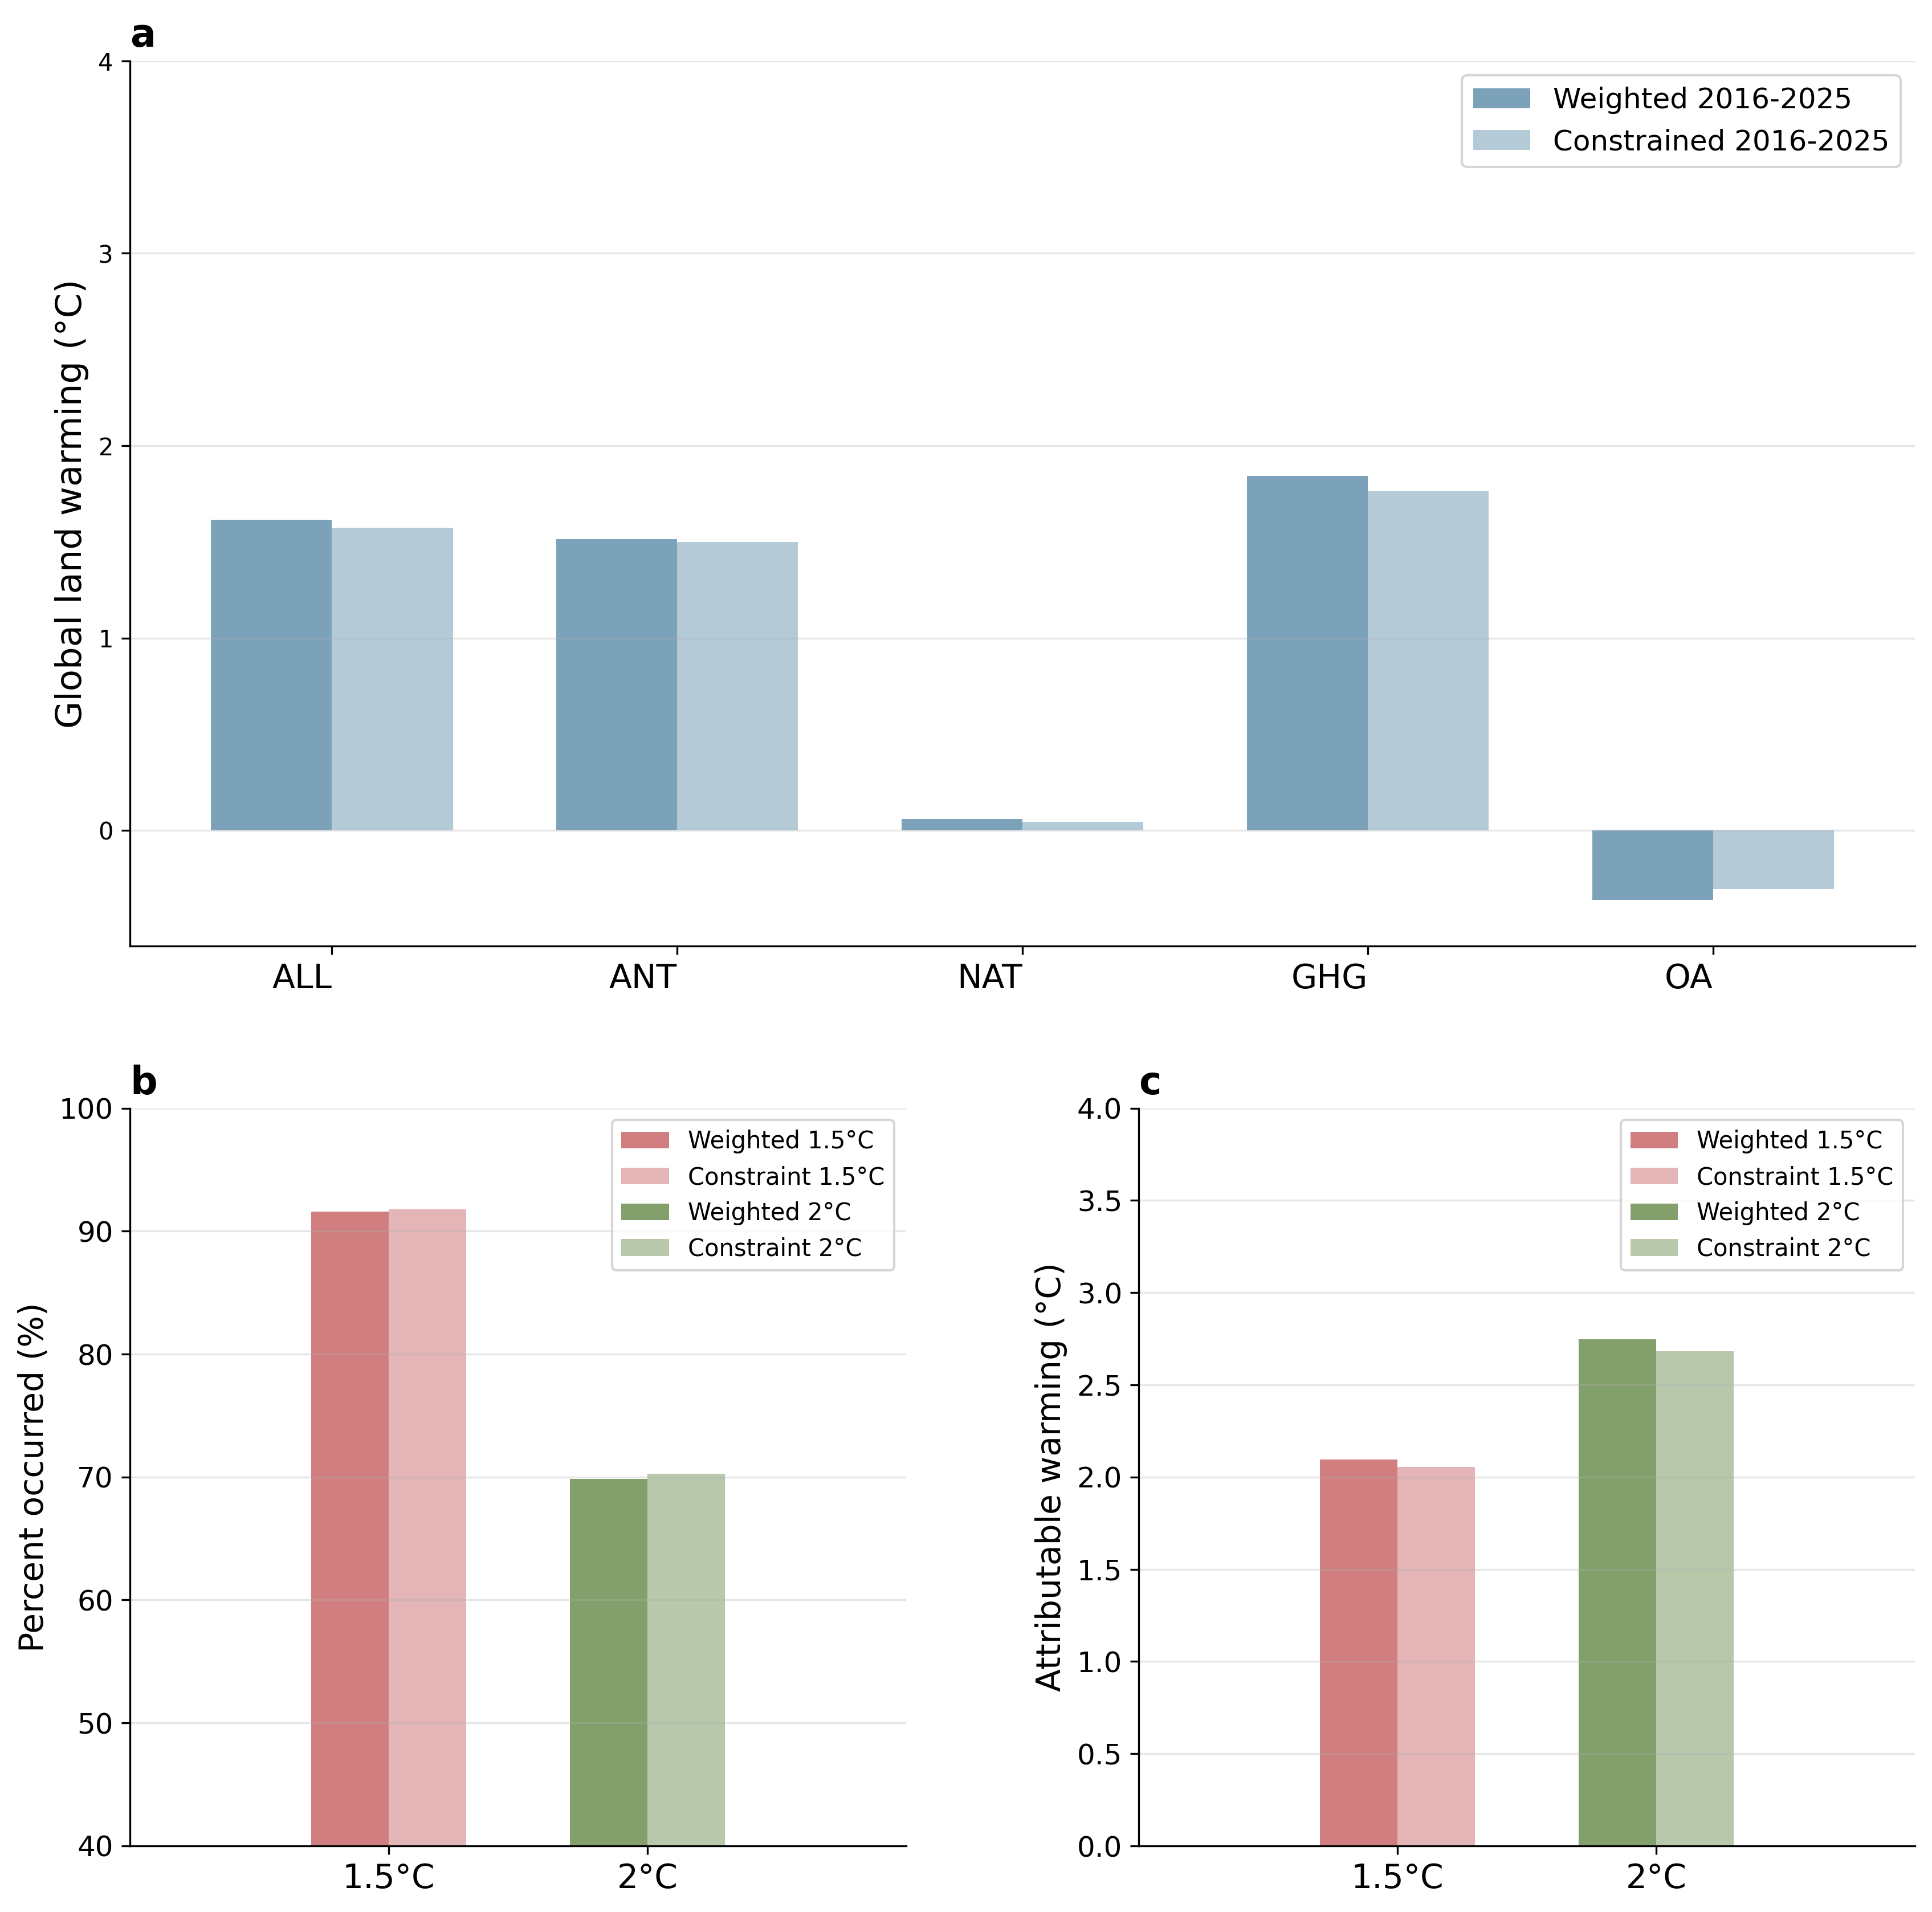

In [84]:
percent_data = {
    "Weighted 1.5°C": percent_reg_15_weighted_glob.values,
    "Constraint 1.5°C": percent_15_constraint_glob.values,
    "Weighted 2°C": percent_reg_2_weighted_glob.values,
    "Constraint 2°C": percent_2_constraint_glob.values,
}

warming_data = {
    "Weighted 1.5°C": warming_reg_15_weighted_glob.values,
    "Constraint 1.5°C": warming_15_constraint_glob.values,
    "Weighted 2°C": warming_reg_2_weighted_glob.values,
    "Constraint 2°C": warming_2_constraint_glob.values,
}
fig = plt.figure(figsize=(12, 12), dpi=300)

plot_global_plus_two_panels(
    global_constrained_warm,
    global_weighted_warm,
    forcings,
    percent_data,
    warming_data
)
fig.savefig('./saved_figures/ED_Fig10.pdf', dpi=300, bbox_inches='tight')
